# Install and Import Libraries


In [ ]:
!pip install umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 5.5 MB/s eta 0:00:00


In [ ]:
pip install faiss-gpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.5/85.5 MB 11.4 MB/s eta 0:00:00


In [ ]:
pip install --upgrade transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 93.7 MB/s eta 0:00:00
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.20.3
    Uninstalling tokenizers-0.20.3:
      Successfully uninstalled tokenizers-0.20.3
  Attempting uninstall: transformers
    Found existing installation: transformers 4.46.3
    Uninstalling transformers-4.46.3:
      Successfully uninstalled transformers-4.46.3


In [ ]:
pip install spektral

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 11.3 MB/s eta 0:00:00


In [ ]:
import json
import pandas as pd
import glob
import random
from concurrent.futures import ThreadPoolExecutor
import sys
import re
from collections import Counter
import os
import datetime
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.image as mpimg
from google.colab import drive
import zipfile
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.sparse import csr_matrix, coo_matrix
from umap import UMAP
import faiss
import tensorflow as tf
import random
import transformers
from spektral.layers import GCNConv
from spektral.data import Graph, DisjointLoader
from spektral.data import Dataset
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.preprocessing.sequence import pad_sequences
from transformers import TFBertModel, BertTokenizer, BertConfig
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Attention
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Model
from tensorflow.keras import activations
from tensorflow.keras.utils import plot_model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.sequence import pad_sequences
from transformers import TFBertForMaskedLM
import tensorflow_hub as hub
import scipy.sparse as sp
from tensorflow.keras.layers import Dense, LayerNormalization, Dropout, Input
import torch
from torch.utils.data import Dataset, DataLoader
from torch import nn
from torch.optim import AdamW
import plotly.express as px
from tqdm import tqdm

/usr/local/lib/python3.10/dist-packages/sentence_transformers/cross_encoder/CrossEncoder.py:13: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


In [ ]:
# Mount Google Drive to access the ZIP file
drive.mount('/content/drive')

Mounted at /content/drive


# Downsampling of the dataset

In [ ]:
"""
# Path to the ZIP file in Google Drive
zip_path = "/content/drive/MyDrive/MSBA 503/spotify_million_playlist_dataset.zip"

# Extract the ZIP file to Colab's /content directory
extract_path = "/content/extracted_data"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Verify extracted files and look inside the 'data' folder
print(f"Extracted files: {os.listdir(extract_path)}")
data_path = os.path.join(extract_path, "data")
if not os.path.exists(data_path):
    raise FileNotFoundError(f"'data' folder not found in {extract_path}")

# Filter for only files matching 'mpd.slice.*.json' in the 'data' folder
file_paths = glob.glob(os.path.join(data_path, "mpd.slice.*.json"))
print(f"Found {len(file_paths)} JSON files matching 'mpd.slice.*.json' in 'data'")

# Shuffle file paths to randomize processing order
random.shuffle(file_paths)

# Define function to process each file
def process_file(file_path):
    with open(file_path, "r") as file:
        data = json.load(file)
        df = pd.json_normalize(
            data['playlists'],
            record_path='tracks',
            meta=[
                'name', 'pid', 'collaborative', 'modified_at', 'num_tracks',
                'num_albums', 'num_followers', 'num_edits', 'duration_ms', 'num_artists'
            ],
            meta_prefix='playlist_',
        )
    return df

# Iterate through files and stop at ~660,000 rows
total_rows = 0
target_rows = 660000
final_dfs = []

for file_path in file_paths:
    df = process_file(file_path)
    if df is not None and not df.empty:
        final_dfs.append(df)
        total_rows += len(df)
        print(f"Processed {file_path}: {len(df)} rows (Total: {total_rows})")
        if total_rows >= target_rows:
            print(f"Reached target of {target_rows} rows. Stopping.")
            break

# Concatenate all collected DataFrames into one
if final_dfs:
    df = pd.concat(final_dfs, ignore_index=True)
    print(df.head())
    print(f"Final dataset size: {df.shape[0]} rows (Target: {target_rows})")
else:
    print("No DataFrames to concatenate")
"""

'\n# Path to the ZIP file in Google Drive\nzip_path = "/content/drive/MyDrive/MSBA 503/spotify_million_playlist_dataset.zip"\n\n# Extract the ZIP file to Colab\'s /content directory\nextract_path = "/content/extracted_data"\nwith zipfile.ZipFile(zip_path, \'r\') as zip_ref:\n    zip_ref.extractall(extract_path)\n\n# Verify extracted files and look inside the \'data\' folder\nprint(f"Extracted files: {os.listdir(extract_path)}")\ndata_path = os.path.join(extract_path, "data")\nif not os.path.exists(data_path):\n    raise FileNotFoundError(f"\'data\' folder not found in {extract_path}")\n\n# Filter for only files matching \'mpd.slice.*.json\' in the \'data\' folder\nfile_paths = glob.glob(os.path.join(data_path, "mpd.slice.*.json"))\nprint(f"Found {len(file_paths)} JSON files matching \'mpd.slice.*.json\' in \'data\'")\n\n# Shuffle file paths to randomize processing order\nrandom.shuffle(file_paths)\n\n# Define function to process each file\ndef process_file(file_path):\n    with open(fi

In [ ]:
"""
output_path = "/content/drive/MyDrive/MSBA 503/msd_downsample.csv"

# Save the DataFrame as a CSV file
df.to_csv(output_path, index=False)

print(f"DataFrame has been saved as a CSV file at: {output_path}")
"""

'\noutput_path = "/content/drive/MyDrive/MSBA 503/msd_downsample.csv"\n\n# Save the DataFrame as a CSV file\ndf.to_csv(output_path, index=False)\n\nprint(f"DataFrame has been saved as a CSV file at: {output_path}")\n'

In [ ]:
path = "/content/drive/MyDrive/MSBA 503/MSBA_503_FINAL_PROJECT/msd_downsample.csv"
df = pd.read_csv(path)
df.head()

,pos,artist_name,track_uri,artist_uri,track_name,album_uri,duration_ms,album_name,playlist_name,playlist_pid,playlist_collaborative,playlist_modified_at,playlist_num_tracks,playlist_num_albums,playlist_num_followers,playlist_num_edits,playlist_duration_ms,playlist_num_artists
0,0,Owl City,spotify:track:5ZkAx8zjLiSs1nMmBwJoZS,spotify:artist:07QEuhtrNmmZ0zEcqE9SF6,When Can I See You Again?,spotify:album:0aqJGQ73RTLu3yLgcdU9JC,218093,Wreck-It Ralph,Rock-ish,786000,False,1509235200,213,122,1,90,44864327,74
1,1,Fall Out Boy,spotify:track:66324Jt0mZdXaM7f8uUitE,spotify:artist:4UXqAaa6dQYAk18Lv7PEgX,Where Did The Party Go,spotify:album:0EVJX4RlYKuApsAN5CaDa3,243040,Save Rock And Roll,Rock-ish,786000,False,1509235200,213,122,1,90,44864327,74
2,2,Panic! At The Disco,spotify:track:6od5hFv9IT5JHc7NEF9HRv,spotify:artist:20JZFwl6HVl6yg8a4H3ZqK,Victorious,spotify:album:6twKQ0EsUJHVlAr6XBylrj,178600,Death Of A Bachelor,Rock-ish,786000,False,1509235200,213,122,1,90,44864327,74
3,3,Fall Out Boy,spotify:track:18GC3F8YPGB8CePXcTUizQ,spotify:artist:4UXqAaa6dQYAk18Lv7PEgX,Thnks fr th Mmrs,spotify:album:03Og8YvbFYbe3hmr9MfZHT,203506,Infinity On High,Rock-ish,786000,False,1509235200,213,122,1,90,44864327,74
4,4,My Darkest Days,spotify:track:376YMK1A83OOtXyo4A7FKi,spotify:artist:64g59lHsc4g2jMFokrKDGW,Stutter,spotify:album:31CFF4SUTpGpcPoACFQ6K7,163320,Sick And Twisted Affair,Rock-ish,786000,False,1509235200,213,122,1,90,44864327,74


In [ ]:
df.shape[0]

665400

In [ ]:
# Define function to process each file
def process_file(file_path):
    with open(file_path, "r") as file:
        data = json.load(file)  # Load JSON data from file
        df = pd.json_normalize(
            data['playlists'],  # Access the playlists list
            record_path='tracks',  # Flatten the tracks key
            meta=[
                'name', 'pid', 'num_tracks', 'num_holdouts', 'num_samples'
            ],  # Include playlist-level metadata
            meta_prefix='playlist_',  # Prefix for metadata columns
            errors='ignore'  # Handle missing keys gracefully
        )
    return df  # Return the processed DataFrame

# Path to validation dataset
validation_file_path = "/content/drive/MyDrive/MSBA 503/MSBA_503_FINAL_PROJECT/challenge_set.json"

# Process the validation file
validation_df = process_file(validation_file_path)

# Display the first few rows of the DataFrame
print(validation_df.head())

   pos artist_name                             track_uri  \
0    0   AronChupa  spotify:track:66U0ASk1VHZsqIkpMjKX3B   
1    1   AronChupa  spotify:track:5MhsZlmKJG6X5kTHkdwC4B   
2    2       Lorde  spotify:track:0GZoB8h0kqXn7XFm4Sj06k   
3    3       Lorde  spotify:track:35kahykNu00FPysz3C2euR   
4    4       Lorde  spotify:track:3G6hD9B2ZHOsgf4WfNu7X1   

                              artist_uri  \
0  spotify:artist:5vCOdeiQt9LyzdI87kt5Sh   
1  spotify:artist:5vCOdeiQt9LyzdI87kt5Sh   
2  spotify:artist:163tK9Wjr9P9DmM0AVK7lm   
3  spotify:artist:163tK9Wjr9P9DmM0AVK7lm   
4  spotify:artist:163tK9Wjr9P9DmM0AVK7lm   

                                          track_name  \
0                                       Little Swing   
1                                   I'm an Albatraoz   
2  Yellow Flicker Beat - From The Hunger Games: M...   
3                                  White Teeth Teens   
4                                               Team   

                              album_u

In [ ]:
validation_df.shape[0]

281000

# Table of Contents

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 665400 entries, 0 to 665399
Data columns (total 18 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   pos                     665400 non-null  int64 
 1   artist_name             665400 non-null  object
 2   track_uri               665400 non-null  object
 3   artist_uri              665400 non-null  object
 4   track_name              665396 non-null  object
 5   album_uri               665400 non-null  object
 6   duration_ms             665400 non-null  int64 
 7   album_name              665399 non-null  object
 8   playlist_name           665400 non-null  object
 9   playlist_pid            665400 non-null  int64 
 10  playlist_collaborative  665400 non-null  bool  
 11  playlist_modified_at    665400 non-null  int64 
 12  playlist_num_tracks     665400 non-null  int64 
 13  playlist_num_albums     665400 non-null  int64 
 14  playlist_num_followers  665400 non-n

In [ ]:
validation_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 281000 entries, 0 to 280999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   pos                    281000 non-null  int64 
 1   artist_name            281000 non-null  object
 2   track_uri              281000 non-null  object
 3   artist_uri             281000 non-null  object
 4   track_name             281000 non-null  object
 5   album_uri              281000 non-null  object
 6   duration_ms            281000 non-null  int64 
 7   album_name             281000 non-null  object
 8   playlist_name          266000 non-null  object
 9   playlist_pid           281000 non-null  object
 10  playlist_num_tracks    281000 non-null  object
 11  playlist_num_holdouts  281000 non-null  object
 12  playlist_num_samples   281000 non-null  object
dtypes: int64(2), object(11)
memory usage: 27.9+ MB


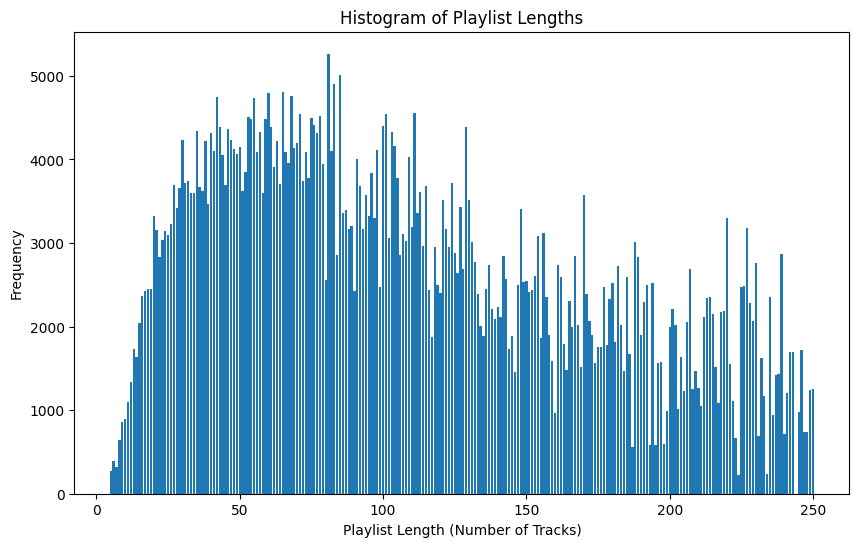

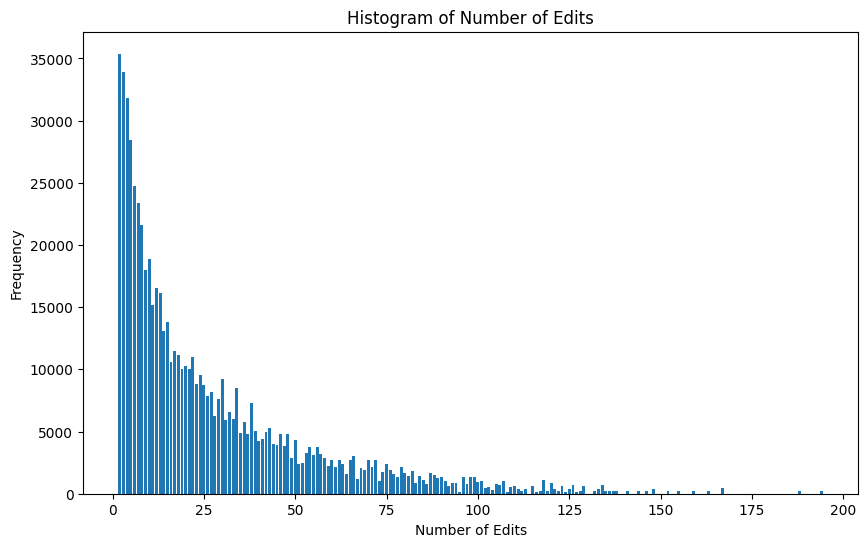

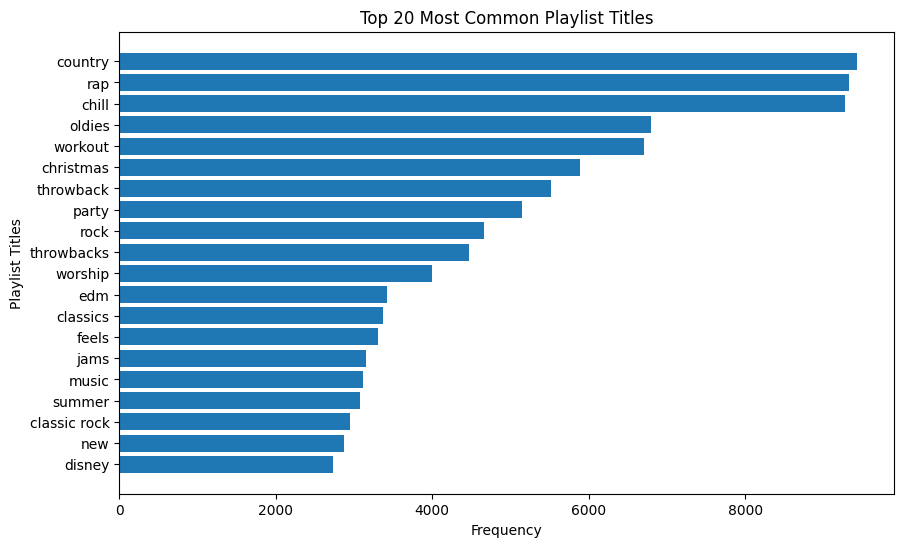

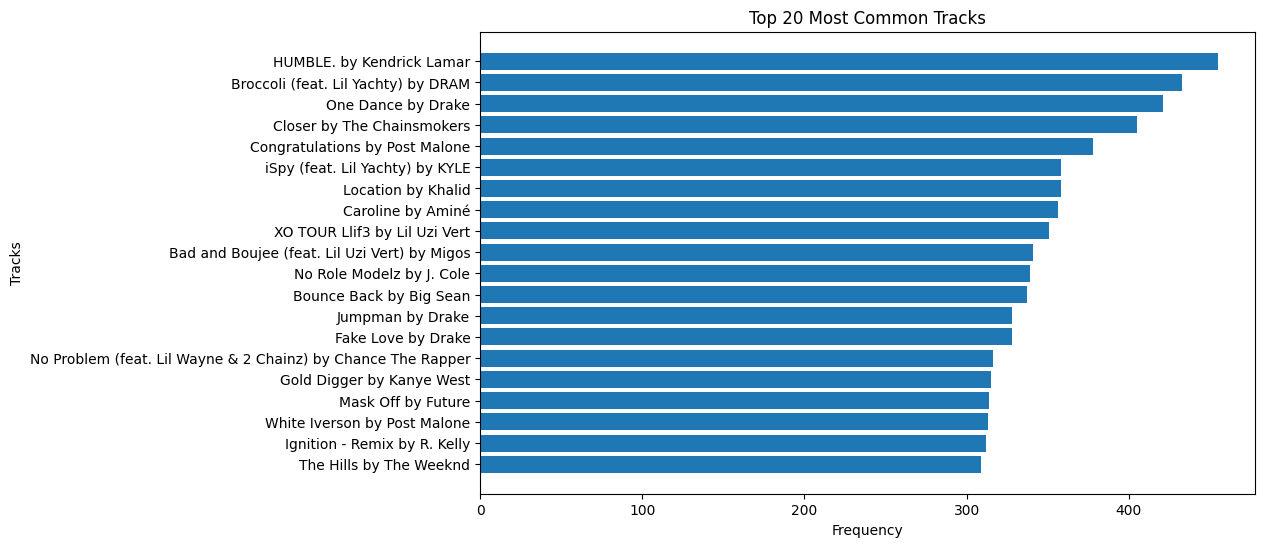

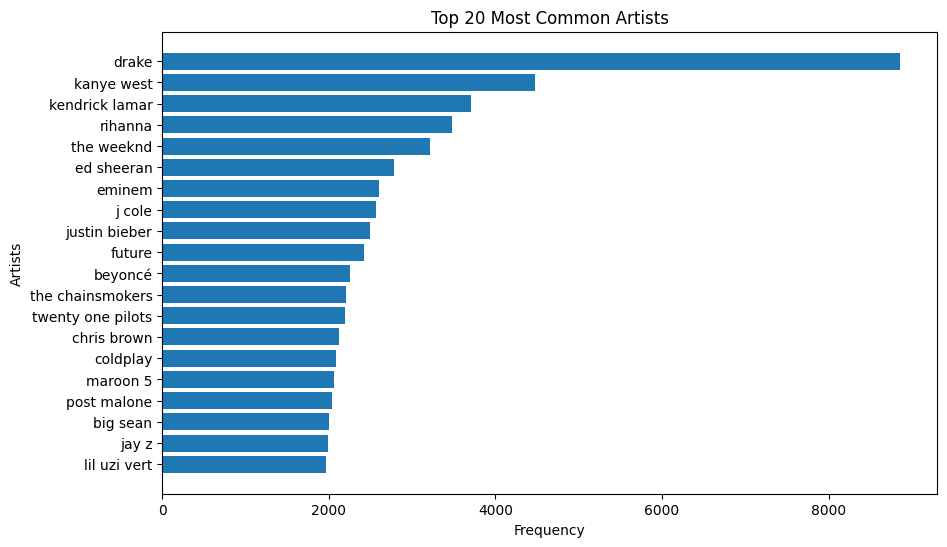

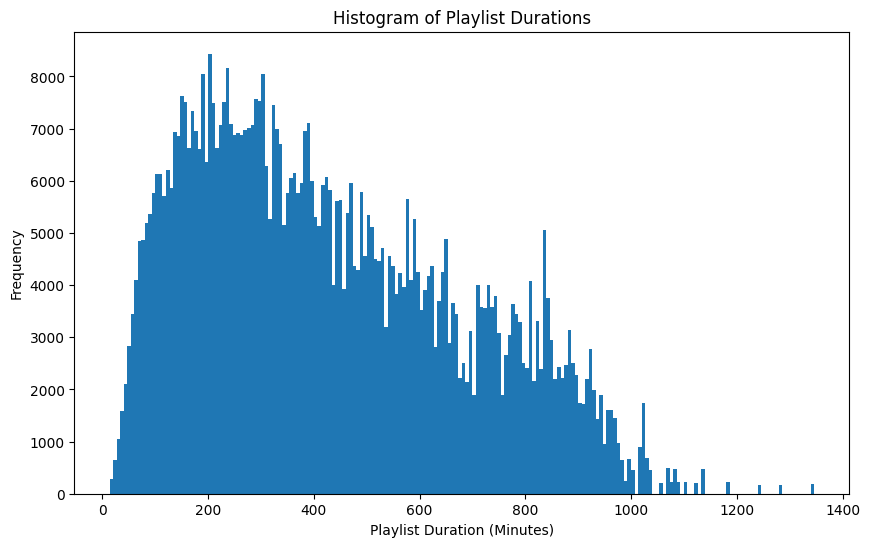

In [ ]:
# Helper Functions
def normalize_name(name):
    if not isinstance(name, str):  # Check if name is a string
        return ""
    name = name.lower()
    name = re.sub(r"[.,\/#!$%\^\*;:{}=\_~()@]", " ", name)
    name = re.sub(r"\s+", " ", name).strip()
    return name

def to_date(epoch):
    try:
        return datetime.datetime.fromtimestamp(epoch).strftime("%Y-%m-%d")
    except (ValueError, TypeError):
        return "Invalid Date"

def df_viz_processing(df):
    # Ensure required columns exist
    required_columns = ['playlist_name', 'playlist_num_tracks', 'playlist_num_edits', 'artist_name', 'track_name']
    for col in required_columns:
        if col not in df.columns:
            raise ValueError(f"Missing required column: {col}")

    # Normalize relevant names
    df['normalized_playlist_name'] = df['playlist_name'].apply(normalize_name)
    df['normalized_album_name'] = df['album_name'].apply(normalize_name) if 'album_name' in df.columns else ""
    df['normalized_artist_name'] = df['artist_name'].apply(normalize_name)
    df['normalized_track_name'] = df['track_name'].apply(normalize_name)
    df['track_display'] = df['track_name'] + " by " + df['artist_name']

    # Convert playlist_modified_at to readable date if available
    if 'playlist_modified_at' in df.columns:
        df['playlist_modified_date'] = df['playlist_modified_at'].apply(to_date)

    # Prepare counters for histograms
    counters = {
        'playlist_name_histogram': Counter(df['normalized_playlist_name']),
        'playlist_length_histogram': Counter(df['playlist_num_tracks']),
        'num_edits_histogram': Counter(df['playlist_num_edits']),
        'artist_histogram': Counter(df['normalized_artist_name']),
        'track_histogram': Counter(df['track_display'])
    }

    return df, counters

def plot_histograms(df, counters):
    # Extract counters
    playlist_name_histogram = counters['playlist_name_histogram']
    playlist_length_histogram = counters['playlist_length_histogram']
    num_edits_histogram = counters['num_edits_histogram']
    artist_histogram = counters['artist_histogram']
    track_histogram = counters['track_histogram']

    # Plot Playlist Length Histogram
    sorted_lengths = sorted(playlist_length_histogram.items())
    lengths, counts = zip(*sorted_lengths)
    plt.figure(figsize=(10, 6))
    plt.bar(lengths, counts)
    plt.xlabel("Playlist Length (Number of Tracks)")
    plt.ylabel("Frequency")
    plt.title("Histogram of Playlist Lengths")
    plt.show()

    # Plot Number of Edits Histogram
    sorted_edits = sorted(num_edits_histogram.items())
    edits, counts = zip(*sorted_edits)
    plt.figure(figsize=(10, 6))
    plt.bar(edits, counts)
    plt.xlabel("Number of Edits")
    plt.ylabel("Frequency")
    plt.title("Histogram of Number of Edits")
    plt.show()

    # Plot Top 20 Playlist Titles
    top_playlists = playlist_name_histogram.most_common(20)
    playlist_names, playlist_counts = zip(*top_playlists)
    plt.figure(figsize=(10, 6))
    plt.barh(playlist_names, playlist_counts)
    plt.xlabel("Frequency")
    plt.ylabel("Playlist Titles")
    plt.title("Top 20 Most Common Playlist Titles")
    plt.gca().invert_yaxis()
    plt.show()

    # Plot Top 20 Tracks
    top_tracks = track_histogram.most_common(20)
    track_names, track_counts = zip(*top_tracks)
    plt.figure(figsize=(10, 6))
    plt.barh(track_names, track_counts)
    plt.xlabel("Frequency")
    plt.ylabel("Tracks")
    plt.title("Top 20 Most Common Tracks")
    plt.gca().invert_yaxis()
    plt.show()

    # Plot Top 20 Artists
    top_artists = artist_histogram.most_common(20)
    artist_names, artist_counts = zip(*top_artists)
    plt.figure(figsize=(10, 6))
    plt.barh(artist_names, artist_counts)
    plt.xlabel("Frequency")
    plt.ylabel("Artists")
    plt.title("Top 20 Most Common Artists")
    plt.gca().invert_yaxis()
    plt.show()

    if 'playlist_duration_ms' in df.columns:
        plt.figure(figsize=(10, 6))
        plt.hist(df['playlist_duration_ms'] / 60000, bins=200)  # Convert ms to minutes
        plt.xlabel("Playlist Duration (Minutes)")
        plt.ylabel("Frequency")
        plt.title("Histogram of Playlist Durations")
        plt.show()

processed_viz_df, hist_counters = df_viz_processing(df)
plot_histograms(processed_viz_df, hist_counters)

In [ ]:
categorical_summary = df.describe(include=['object'])
print(categorical_summary)

       artist_name                             track_uri  \
count       665400                                665400   
unique       35968                                171844   
top          Drake  spotify:track:7KXjTSCq5nL1LoYtL7XAwS   
freq          8861                                   455   

                                   artist_uri track_name  \
count                                  665400     665396   
unique                                  36258     134193   
top     spotify:artist:3TVXtAsR1Inumwj472S9r4     Closer   
freq                                     8861        694   

                                   album_uri album_name playlist_name  \
count                                 665400     665399        665400   
unique                                 82533      70254          6045   
top     spotify:album:5s0rmjP8XOPhP6HhqOhuyC      Views       Country   
freq                                    1650       2101          5378   

       normalized_playlist_name 

# Data Preprocessing / Feature Engineering

In [ ]:
# Initialize Sentence-BERT model
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')

# Normalize Numerical Columns
def normalize_numerical_columns(df, columns):
    """Apply log transformation to numerical columns."""
    for column in columns:
        if column in df.columns:
            df[column] = np.log1p(df[column])  # log(1 + x) to handle 0 values
    return df

# Create Unique IDs for Tracks, Albums, Artists
def create_unique_ids(df):
    df['track_id'] = df['track_uri'].astype('category').cat.codes
    df['album_id'] = df['album_uri'].astype('category').cat.codes
    df['artist_id'] = df['artist_uri'].astype('category').cat.codes
    return df

# Compute Playlist-Level Features
def compute_playlist_features(df):
    df['edit_frequency'] = df['playlist_num_edits'] / (df['playlist_modified_at'] + 1e-9)
    df['unique_artists'] = df.groupby('playlist_name')['artist_uri'].transform('nunique')
    df['unique_albums'] = df.groupby('playlist_name')['album_uri'].transform('nunique')
    df['days_since_last_edit'] = (datetime.datetime.now().timestamp() - df['playlist_modified_at']) / (60 * 60 * 24)
    df['same_artist_ratio'] = df.groupby('playlist_name')['artist_uri'].transform(
        lambda x: x.value_counts().max() / len(x)
    )
    df['same_album_ratio'] = df.groupby('playlist_name')['album_uri'].transform(
        lambda x: x.value_counts().max() / len(x)
    )
    df['track_diversity'] = df['unique_artists'] / df['playlist_num_tracks']
    df['artist_diversity'] = df['unique_artists'] / df['playlist_num_tracks']
    df['album_diversity'] = df['unique_albums'] / df['playlist_num_tracks']

    # Calculate diversity score as a weighted average
    df['diversity_score'] = (df['artist_diversity'] + df['album_diversity'] + df['track_diversity']) / 3

    # Normalize diversity score to [1e-6, 1]
    df['diversity_score'] = (df['diversity_score'] - df['diversity_score'].min()) / (
        df['diversity_score'].max() - df['diversity_score'].min() + 1e-8
    )
    df['diversity_score'] = 0.1 + 0.9 * df['diversity_score']

    return df

# Compute Track-Level Features
def compute_track_features(df):
    df['avg_duration_per_artist'] = df.groupby('artist_uri')['duration_ms'].transform('mean')
    df['avg_duration_per_album'] = df.groupby('album_uri')['duration_ms'].transform('mean')
    return df

# Encode Playlist Names with Sentence-BERT
def encode_playlist_name(df):
    unique_names = df['normalized_playlist_name'].unique()
    name_to_embedding = {name: sbert_model.encode(name) for name in unique_names if isinstance(name, str)}
    df['playlist_name_embedding'] = df['normalized_playlist_name'].map(name_to_embedding)
    return df

def prepare_sequences(df):
    # Group by playlist_name to create sequences
    grouped_sequences = df.groupby('playlist_name').agg({
        'track_id': list,
        'album_id': list,
        'artist_id': list
    }).reset_index()

    # Rename columns for clarity
    grouped_sequences.rename(columns={
        'track_id': 'track_sequence',
        'album_id': 'album_sequence',
        'artist_id': 'artist_sequence'
    }, inplace=True)

    # Merge sequences back with the original DataFrame to retain other features
    df = df.drop_duplicates(subset=['playlist_name'])
    df = pd.merge(df, grouped_sequences, on='playlist_name', how='inner')

    # Reset index
    df.reset_index(drop=True, inplace=True)

    return df


# Main Processing Function
def df_processing(df):
    # Required columns
    required_columns = [
        'playlist_name', 'playlist_num_tracks', 'playlist_num_edits', 'artist_name',
        'track_name', 'track_uri', 'album_uri', 'artist_uri', 'duration_ms', 'playlist_modified_at'
    ]
    for col in required_columns:
        if col not in df.columns:
            raise ValueError(f"Missing required column: {col}")

    # Normalize textual fields
    df['normalized_playlist_name'] = df['playlist_name'].apply(normalize_name)
    df['normalized_album_name'] = df['album_name'].apply(normalize_name) if 'album_name' in df.columns else ""
    df['normalized_artist_name'] = df['artist_name'].apply(normalize_name)
    df['normalized_track_name'] = df['track_name'].apply(normalize_name)
    df['track_display'] = df['track_name'] + " by " + df['artist_name']

    # Normalize numerical columns
    numerical_columns = ['duration_ms', 'playlist_num_tracks', 'playlist_num_edits']
    df = normalize_numerical_columns(df, numerical_columns)

    # Create unique IDs
    df = create_unique_ids(df)

    # Compute features
    df = compute_playlist_features(df)
    df = compute_track_features(df)

    # Encode playlist names
    df = encode_playlist_name(df)

    # Prepare sequences
    df = prepare_sequences(df)

    return df

df = df_processing(df)
print(df.head())

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.7k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

1_Pooling/config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

   pos                    artist_name                             track_uri  \
0    0                       Owl City  spotify:track:5ZkAx8zjLiSs1nMmBwJoZS   
1    0  The Ozark Mountain Daredevils  spotify:track:6UToZMxYTBLaLOGCI8CRwp   
2    0                John Mellencamp  spotify:track:43btz2xjMKpcmjkuRsvxyg   
3    0                  Rascal Flatts  spotify:track:1SLikaDhWhhhnLJC58bkFI   
4    0                          Birdy  spotify:track:5vuwXvQTpavYCgcPFnCMS4   

                              artist_uri                 track_name  \
0  spotify:artist:07QEuhtrNmmZ0zEcqE9SF6  When Can I See You Again?   
1  spotify:artist:7jM2XoJBKhdL8oNnDr4re9       Standing On The Rock   
2  spotify:artist:3lPQ2Fk5JOwGWAF3ORFCqH               Jack & Diane   
3  spotify:artist:0a1gHP0HAqALbEyxaD5Ngn          Life Is A Highway   
4  spotify:artist:2WX2uTcsvV5OnS0inACecP       Keeping Your Head Up   

                              album_uri  duration_ms  \
0  spotify:album:0aqJGQ73RTLu3yLgcdU9JC   

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6045 entries, 0 to 6044
Data columns (total 43 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pos                       6045 non-null   int64  
 1   artist_name               6045 non-null   object 
 2   track_uri                 6045 non-null   object 
 3   artist_uri                6045 non-null   object 
 4   track_name                6045 non-null   object 
 5   album_uri                 6045 non-null   object 
 6   duration_ms               6045 non-null   float64
 7   album_name                6045 non-null   object 
 8   playlist_name             6045 non-null   object 
 9   playlist_pid              6045 non-null   int64  
 10  playlist_collaborative    6045 non-null   bool   
 11  playlist_modified_at      6045 non-null   int64  
 12  playlist_num_tracks       6045 non-null   float64
 13  playlist_num_albums       6045 non-null   int64  
 14  playlist

In [ ]:
print(df['diversity_score'])
print(df['playlist_name_embedding'])
# Count the total number of values in the playlist embeddings column
total_playlists_embeddings = sum(len(seq) for seq in df['playlist_name_embedding'])
print(f"The total number of values in the df playlist_embeddings column is: {total_playlists_embeddings}")


0       0.119013
1       0.118069
2       0.134026
3       0.131321
4       0.145110
          ...   
6040    0.108502
6041    0.105155
6042    0.107471
6043    0.104704
6044    0.110360
Name: diversity_score, Length: 6045, dtype: float64
0       [-0.041375823, 0.032450583, 0.036814287, -0.03...
1       [-0.09396398, 0.02384952, 0.012299512, 0.06400...
2       [-0.014195988, 0.04601856, -0.02884843, 0.0020...
3       [0.028235113, -0.01187246, 0.029072484, 0.0415...
4       [-0.07082565, -0.08349472, 0.034402136, 0.0498...
                              ...                        
6040    [0.061562497, -0.011229672, -0.046243932, 0.02...
6041    [-0.044889502, 0.07257196, 0.02973744, -0.0028...
6042    [0.04888576, 0.04127316, 0.07838278, 0.0171254...
6043    [-0.029753838, 0.00037511802, 0.07483877, 0.08...
6044    [0.01958679, 0.04004123, 0.009051351, 0.029606...
Name: playlist_name_embedding, Length: 6045, dtype: object
The total number of values in the df playlist_embeddings column 

In [ ]:
# Count the total number of values in the track_sequence column
total_values = sum(len(seq) for seq in df['track_sequence'])
print(f"The total number of values in the df track_sequence column is: {total_values}")


The total number of values in the df track_sequence column is: 665400


# Validation Preprocessing

In [ ]:
# Initialize Sentence-BERT model
sbert_model_val = SentenceTransformer('all-MiniLM-L6-v2')

# Create Unique IDs for Tracks, Albums, Artists
def create_unique_ids(df):
    df['track_id'] = df['track_uri'].astype('category').cat.codes
    df['album_id'] = df['album_uri'].astype('category').cat.codes
    df['artist_id'] = df['artist_uri'].astype('category').cat.codes
    return df

# Compute Playlist-Level Features
def compute_playlist_features(df):
    df['unique_artists'] = df.groupby('playlist_name')['artist_uri'].transform('nunique')
    df['unique_albums'] = df.groupby('playlist_name')['album_uri'].transform('nunique')
    df['same_artist_ratio'] = df.groupby('playlist_name')['artist_uri'].transform(
        lambda x: x.value_counts().max() / len(x)
    )
    df['same_album_ratio'] = df.groupby('playlist_name')['album_uri'].transform(
        lambda x: x.value_counts().max() / len(x)
    )
    df['track_diversity'] = df['unique_artists'] / df['playlist_num_tracks']
    df['artist_diversity'] = df['unique_artists'] / df['playlist_num_tracks']
    df['album_diversity'] = df['unique_albums'] / df['playlist_num_tracks']

    # Calculate diversity score as a raw average without normalization
    df['diversity_score'] = (df['artist_diversity'] + df['album_diversity'] + df['track_diversity']) / 3
    return df

# Compute Track-Level Features
def compute_track_features(df):
    df['avg_duration_per_artist'] = df.groupby('artist_uri')['duration_ms'].transform('mean')
    df['avg_duration_per_album'] = df.groupby('album_uri')['duration_ms'].transform('mean')
    return df

# Encode Playlist Names with Sentence-BERT
def encode_playlist_name(df):
    unique_names = df['normalized_playlist_name'].unique()
    name_to_embedding = {name: sbert_model_val.encode(name) for name in unique_names if isinstance(name, str)}
    df['playlist_name_embedding'] = df['normalized_playlist_name'].map(name_to_embedding)
    return df

# Prepare Sequences
def prepare_sequences(df):
    # Group by playlist_name to create sequences
    grouped_sequences = df.groupby('playlist_name').agg({
        'track_id': list,
        'album_id': list,
        'artist_id': list
    }).reset_index()

    # Rename columns for clarity
    grouped_sequences.rename(columns={
        'track_id': 'track_sequence',
        'album_id': 'album_sequence',
        'artist_id': 'artist_sequence'
    }, inplace=True)

    # Merge sequences back with the original DataFrame to retain other features
    df = df.drop_duplicates(subset=['playlist_name'])
    df = pd.merge(df, grouped_sequences, on='playlist_name', how='inner')

    # Reset index
    df.reset_index(drop=True, inplace=True)

    return df

# Main Processing Function
def df_processing(df):
    # Required columns
    required_columns = [
        'playlist_name', 'playlist_num_tracks', 'artist_name',
        'track_name', 'track_uri', 'album_uri', 'artist_uri', 'duration_ms'
    ]
    for col in required_columns:
        if col not in df.columns:
            raise ValueError(f"Missing required column: {col}")

    # Normalize textual fields
    df['normalized_playlist_name'] = df['playlist_name'].apply(normalize_name)
    df['normalized_album_name'] = df['album_name'].apply(normalize_name) if 'album_name' in df.columns else ""
    df['normalized_artist_name'] = df['artist_name'].apply(normalize_name)
    df['normalized_track_name'] = df['track_name'].apply(normalize_name)
    df['track_display'] = df['track_name'] + " by " + df['artist_name']

    # Skip normalization of numerical columns
    # Create unique IDs
    df = create_unique_ids(df)

    # Compute features
    df = compute_playlist_features(df)
    df = compute_track_features(df)

    # Encode playlist names
    df = encode_playlist_name(df)

    # Prepare sequences
    df = prepare_sequences(df)

    return df

# Process the validation DataFrame
validation_df = df_processing(validation_df)
print(validation_df.head())


   pos   artist_name                             track_uri  \
0    0     AronChupa  spotify:track:66U0ASk1VHZsqIkpMjKX3B   
1    0        Alesso  spotify:track:6WQLkih8nE0JdUCEyLaGnQ   
2    0         Banks  spotify:track:4PvD06Pmbm2rHG2JjSlElF   
3    0      Galantis  spotify:track:6fKEplI9iN0JMHsRGQESaT   
4    0  Stick Figure  spotify:track:3ik1fFvzdgmVuiob8t8NlG   

                              artist_uri            track_name  \
0  spotify:artist:5vCOdeiQt9LyzdI87kt5Sh          Little Swing   
1  spotify:artist:4AVFqumd2ogHFlRbKIjp1t  Heroes (we could be)   
2  spotify:artist:2xe8IXgCTpwHE3eA9hTs4n     Beggin For Thread   
3  spotify:artist:4sTQVOfp9vEMCemLw50sbu              Firebird   
4  spotify:artist:5SXEylV07TC57eanSxxg4R           All My Love   

                              album_uri  duration_ms    album_name  \
0  spotify:album:4S5MLjwRSi0NJ5nikflYnZ       163809  Little Swing   
1  spotify:album:3yqh9ozOA2cAgPUJaveAuG       210012       Forever   
2  spotify:album:1ee

In [ ]:
# Count the total number of values in the track_sequence column
total_values = sum(len(seq) for seq in validation_df['track_sequence'])
print(f"The total number of values in the validation track_sequence column is: {total_values}")


The total number of values in the validation track_sequence column is: 266000


In [ ]:
train_tracks = set(df['track_id'])
val_tracks = set(validation_df['track_id'])
overlap_ratio = len(train_tracks & val_tracks) / len(val_tracks)
print(f"Overlap Ratio: {overlap_ratio:.2%}")


Overlap Ratio: 2.96%


In [ ]:
print("Is GPU available:", tf.test.is_gpu_available())

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


Is GPU available: True


# Word 2 Vec Model

In [ ]:
df['track_sequence']

,track_sequence
0,"[123049, 134490, 150479, 25256, 68672, 57490, ..."
1,"[143240, 70129, 46532, 108269, 30790, 16307, 6..."
2,"[89640, 116877, 59236, 106224, 73427, 100575, ..."
3,"[32331, 92754, 14104, 131698, 26087, 140596, 1..."
4,"[130956, 113998, 8971, 156875, 122304, 59169, ..."
...,...
6040,"[54303, 107810, 121071, 54022, 104234, 139351,..."
6041,"[140352, 141879, 135131, 97694, 141539, 143250..."
6042,"[46517, 165181, 57826, 15695, 145570, 170573, ..."
6043,"[138430, 161391, 134021, 24792, 86055, 78744, ..."


Vocabulary Size: 171844, Total Samples: 665400, Steps per Epoch: 1299
Epoch 1/5
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 136s 102ms/step - binary_accuracy: 0.9287 - loss: 0.3859
Epoch 2/5
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 132s 102ms/step - binary_accuracy: 0.9558 - loss: 0.2613
Epoch 3/5
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 132s 101ms/step - binary_accuracy: 0.9552 - loss: 0.2870
Epoch 4/5
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 133s 102ms/step - binary_accuracy: 0.9442 - loss: 0.3343
Epoch 5/5
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 131s 101ms/step - binary_accuracy: 0.9617 - loss: 0.2439
Restoring model weights from the end of the best epoch: 3.
Training completed successfully.


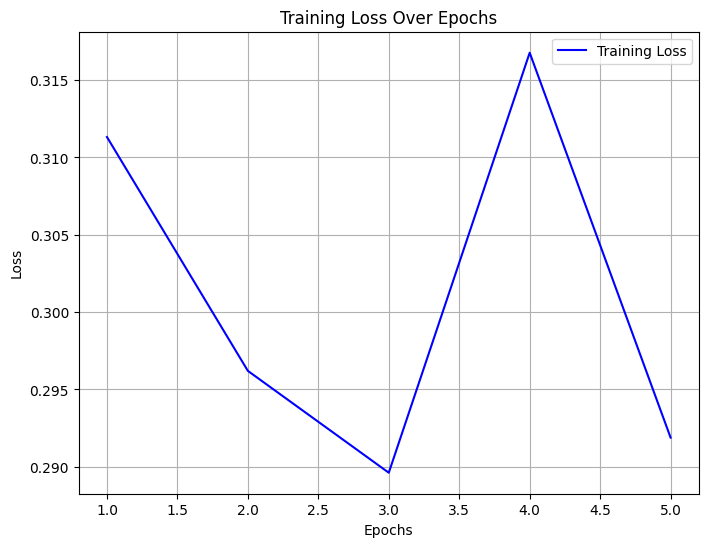

In [ ]:
# Parameters
EMBEDDING_DIM = 128  # Size of the embedding vectors
BATCH_SIZE = 512
EPOCHS = 5
WINDOW_SIZE = 5
NUM_NEG_SAMPLES = 6
LEARNING_RATE = 0.01


# Prepare data
def prepare_data(df, column):
    """Prepare data for TensorFlow training without frequency filtering."""
    # Flatten sequences into a single list of "sentences"
    sentences = df[column].tolist()

    # Create a vocabulary without filtering
    unique_items = {item for sentence in sentences for item in sentence}
    vocab_size = len(unique_items)

    # Create mappings
    item_to_id = {item: idx for idx, item in enumerate(unique_items)}
    id_to_item = {idx: item for item, idx in item_to_id.items()}

    # Convert sentences to sequences of IDs
    sentences_as_ids = [
        [item_to_id[item] for item in sentence]
        for sentence in sentences
    ]
    return sentences_as_ids, vocab_size, item_to_id, id_to_item


# Create dataset with negative sampling
def create_dataset_with_neg_sampling(sequences, vocab_size, window_size=5, num_ns=4):
    """Generate skip-grams with negative sampling for track_uri."""
    def generate_skip_grams_with_ns(sequence):
        for idx, target in enumerate(sequence):
            start = max(0, idx - window_size)
            end = min(len(sequence), idx + window_size + 1)
            positive_context = sequence[start:idx] + sequence[idx + 1:end]
            for context in positive_context:
                yield target, context, 1  # Positive pair
                for _ in range(num_ns):
                    negative_sample = np.random.randint(0, vocab_size)
                    while negative_sample in positive_context:
                        negative_sample = np.random.randint(0, vocab_size)
                    yield target, negative_sample, 0  # Negative pair

    dataset = tf.data.Dataset.from_generator(
        lambda: (pair for sequence in sequences for pair in generate_skip_grams_with_ns(sequence)),
        output_signature=(
            tf.TensorSpec(shape=(), dtype=tf.int32),
            tf.TensorSpec(shape=(), dtype=tf.int32),
            tf.TensorSpec(shape=(), dtype=tf.float32),
        )
    )

    # Map dataset to model inputs and labels
    def map_to_model_inputs(target, context, label):
        inputs = {"track_uri": target, "context": context}
        return inputs, label

    dataset = dataset.map(map_to_model_inputs)
    dataset = dataset.shuffle(buffer_size=10000).batch(BATCH_SIZE, drop_remainder=True).prefetch(tf.data.AUTOTUNE)

    return dataset


# Build model
def build_skip_gram_model(vocab_size, embedding_dim):
    """Build a skip-gram model for track_uri embeddings."""
    # Input layers
    target_input = tf.keras.layers.Input(shape=(), dtype=tf.int32, name="track_uri")
    context_input = tf.keras.layers.Input(shape=(), dtype=tf.int32, name="context")

    # Embedding layers
    embedding_layer = tf.keras.layers.Embedding(
        vocab_size, embedding_dim, embeddings_regularizer=tf.keras.regularizers.l2(1e-6), name="track_uri_embedding"
    )
    target_embedding = embedding_layer(target_input)
    context_embedding = embedding_layer(context_input)

    # Dot product to compute similarity
    dot_product = tf.keras.layers.Dot(axes=-1)([target_embedding, context_embedding])
    output = tf.keras.layers.Dense(1, activation="sigmoid")(dot_product)

    model = tf.keras.Model(inputs={"track_uri": target_input, "context": context_input}, outputs=output)
    return model


# Train embeddings
def train_track_uri_embeddings(df, column):
    """Train track_uri embeddings using skip-gram with negative sampling."""
    # Prepare data
    sequences, vocab_size, item_to_id, id_to_item = prepare_data(df, column)
    if vocab_size == 0 or not sequences:
        raise ValueError("Vocabulary size or sequences are empty. Check your input data.")

    # Create dataset
    dataset = create_dataset_with_neg_sampling(sequences, vocab_size, WINDOW_SIZE, NUM_NEG_SAMPLES)

    # Build model
    model = build_skip_gram_model(vocab_size, EMBEDDING_DIM)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="binary_crossentropy",
        metrics=["binary_accuracy"],
    )

    # Train model
    total_samples = sum(len(seq) for seq in sequences)
    steps_per_epoch = max(1, total_samples // BATCH_SIZE)
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="loss", patience=3, restore_best_weights=True, verbose=1
    )

    print(f"Vocabulary Size: {vocab_size}, Total Samples: {total_samples}, Steps per Epoch: {steps_per_epoch}")

    history = model.fit(dataset, epochs=EPOCHS, steps_per_epoch=steps_per_epoch, callbacks=[early_stopping])

    # Extract trained embeddings
    embeddings = model.get_layer("track_uri_embedding").get_weights()[0]

    return embeddings, item_to_id, id_to_item, history

def plot_training_history(history):
    """Plot the training loss over epochs."""
    loss = history.history['loss']
    epochs = range(1, len(loss) + 1)

    plt.figure(figsize=(8, 6))
    plt.plot(epochs, loss, 'b-', label='Training Loss')
    plt.title('Training Loss Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()
    plt.show()


# Main Execution
if __name__ == "__main__":
    if 'track_sequence' not in df.columns:
        raise ValueError("'track_sequence' column not found in the DataFrame.")

    try:
        track_embeddings, track_item_to_id, track_id_to_item, history = train_track_uri_embeddings(df, column="track_sequence")
        print("Training completed successfully.")

        # Plot training history
        plot_training_history(history)
    except ValueError as e:
        print(f"Error during training: {e}")



# Word 2 Vec Model Validation

Available tracks in vocabulary:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Using sample track for validation: 0
Visualizing embeddings:


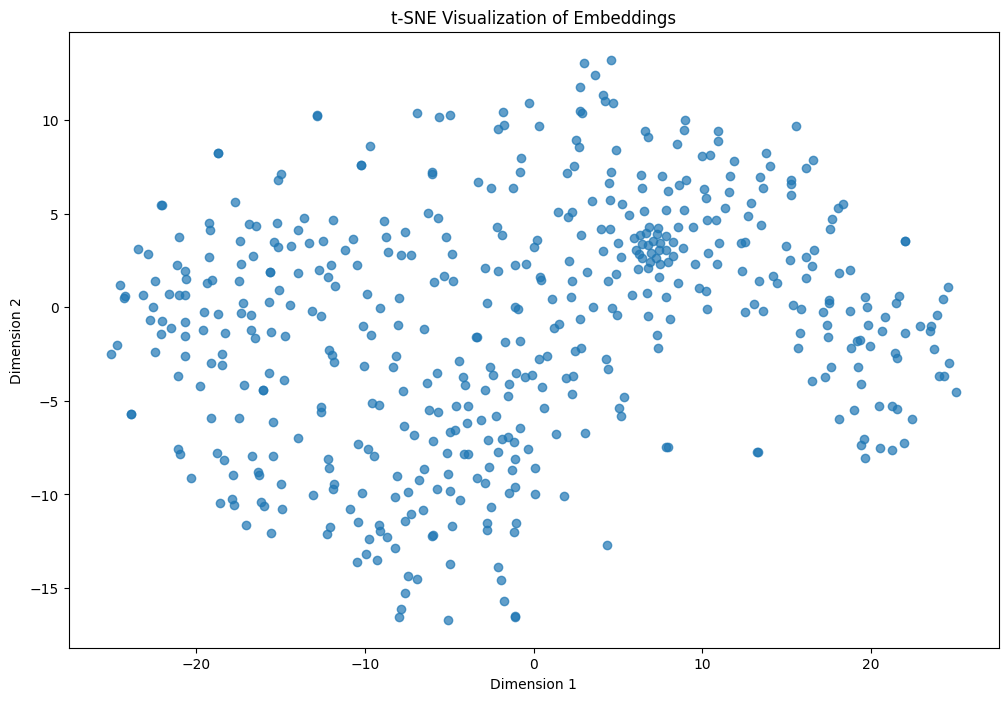

In [ ]:
def visualize_embeddings(embeddings, item_to_id, id_to_item, labels=None, num_samples=500):
    """
    Visualize embeddings using t-SNE.
    - embeddings: Trained embedding matrix
    - item_to_id: Mapping from items to IDs
    - id_to_item: Mapping from IDs to items
    - labels: Optional labels for coloring points (e.g., playlists, artists)
    - num_samples: Number of points to sample for visualization
    """

    # Randomly sample items for visualization
    sampled_ids = np.random.choice(len(embeddings), size=min(num_samples, len(embeddings)), replace=False)
    sampled_embeddings = embeddings[sampled_ids]
    sampled_items = [id_to_item[idx] for idx in sampled_ids]

    # Reduce dimensions with t-SNE
    tsne = TSNE(n_components=2, random_state=42)
    reduced_embeddings = tsne.fit_transform(sampled_embeddings)

    # Plot
    plt.figure(figsize=(12, 8))
    if labels:
        sampled_labels = [labels[item] if item in labels else 'Unknown' for item in sampled_items]
        for label in set(sampled_labels):
            indices = [i for i, lbl in enumerate(sampled_labels) if lbl == label]
            plt.scatter(reduced_embeddings[indices, 0], reduced_embeddings[indices, 1], label=label, alpha=0.7)
        plt.legend()
    else:
        plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], alpha=0.7)

    plt.title("t-SNE Visualization of Embeddings")
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.show()

# Debugging: List all track uris in the vocabulary
print("Available tracks in vocabulary:")
print(list(track_item_to_id.keys())[:10])  # Display first 10 tracks for inspection

# Pick a valid track for validation
sample_track = list(track_item_to_id.keys())[0]  # Use the first track in the mapping
print(f"Using sample track for validation: {sample_track}")

# Visualize track embeddings
print("Visualizing embeddings:")
visualize_embeddings(track_embeddings, track_item_to_id, track_id_to_item)

/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
<ipython-input-28-2c450688d552>:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab20', len(unique_labels))  # Use 'tab20' for distinct colors


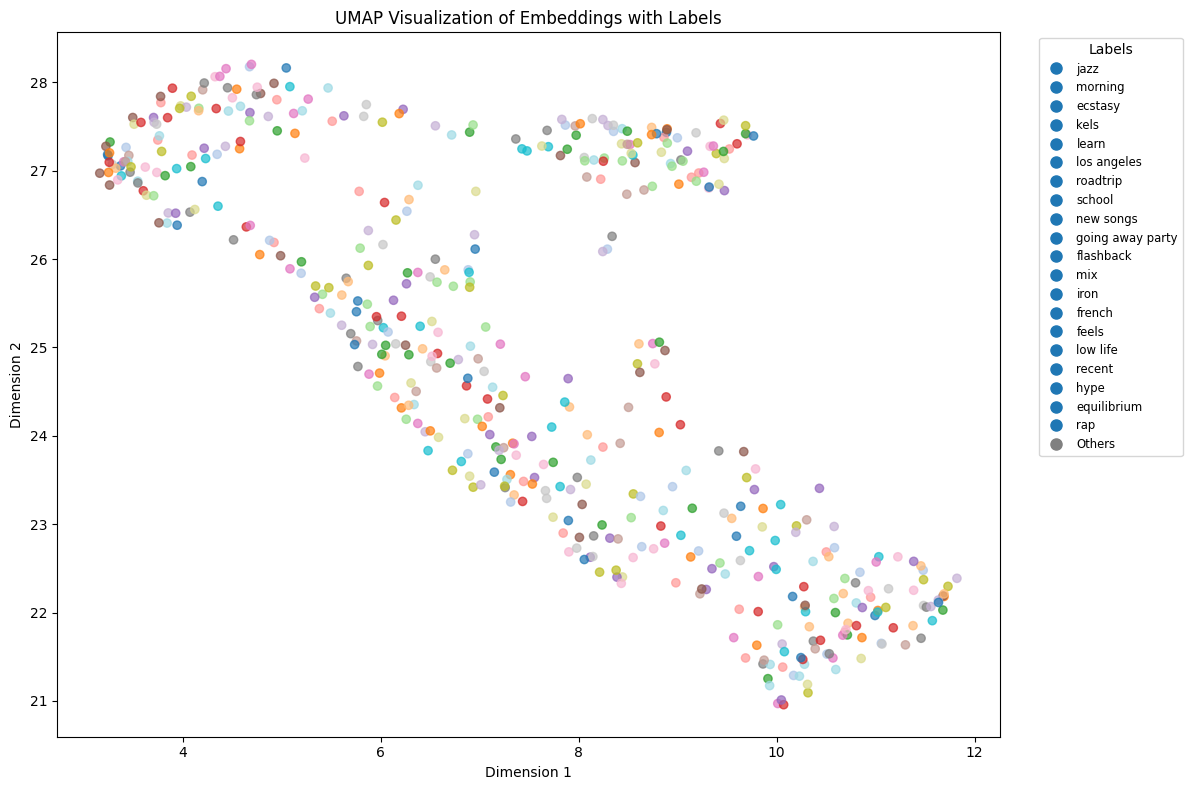

In [ ]:
# Function to map track IDs to playlist names
def create_playlist_labels(df):
    """Create a dictionary mapping track_id to normalized_playlist_name."""
    playlist_labels = {}
    for playlist_name, track_ids in zip(df['normalized_playlist_name'], df['track_sequence']):
        for track_id in track_ids:
            playlist_labels[track_id] = playlist_name
    return playlist_labels

# Visualization Function
def visualize_embeddings_with_labels(embeddings, item_to_id, id_to_item, labels, num_samples=500, legend_max_items=20):
    """Visualize embeddings using UMAP and color by labels."""
    # Randomly sample items for visualization
    sampled_ids = np.random.choice(len(embeddings), size=min(num_samples, len(embeddings)), replace=False)
    sampled_embeddings = embeddings[sampled_ids]
    sampled_labels = [labels.get(id_to_item[idx], 'Unknown') for idx in sampled_ids]

    # Reduce dimensions with UMAP
    umap = UMAP(n_components=2, random_state=42)
    reduced_embeddings = umap.fit_transform(sampled_embeddings)

    # Map labels to unique integers for coloring
    unique_labels = list(set(sampled_labels))
    label_to_color = {label: idx for idx, label in enumerate(unique_labels)}
    numeric_labels = [label_to_color[label] for label in sampled_labels]

    # Define a colormap
    cmap = cm.get_cmap('tab20', len(unique_labels))  # Use 'tab20' for distinct colors
    norm = mcolors.Normalize(vmin=0, vmax=len(unique_labels) - 1)

    # Plot UMAP results
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], alpha=0.7,
                          c=numeric_labels, cmap=cmap, norm=norm)

    # Add a legend with a limited number of unique labels
    if len(unique_labels) > legend_max_items:
        legend_labels = unique_labels[:legend_max_items] + ["Others"]
        colors = [cmap(norm(idx)) for idx in range(legend_max_items)] + ['gray']
    else:
        legend_labels = unique_labels
        colors = [cmap(norm(idx)) for idx in range(len(unique_labels))]

    handles = [plt.Line2D([0], [0], marker='o', color=color, linestyle='None', markersize=8)
               for color in colors]

    plt.legend(handles, legend_labels, loc='upper right', bbox_to_anchor=(1.2, 1), title="Labels", fontsize='small')

    plt.title("UMAP Visualization of Embeddings with Labels")
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.tight_layout()
    plt.show()

# Main Execution
if __name__ == "__main__":
    # Ensure that your DataFrame contains 'normalized_playlist_name' and 'track_sequence'
    if 'normalized_playlist_name' not in df.columns or 'track_sequence' not in df.columns:
        raise ValueError("Columns 'normalized_playlist_name' and 'track_sequence' must exist in the DataFrame.")

    # Create playlist labels mapping
    playlist_labels = create_playlist_labels(df)

    # Visualize embeddings
    visualize_embeddings_with_labels(
        embeddings=track_embeddings,
        item_to_id=track_item_to_id,
        id_to_item=track_id_to_item,
        labels=playlist_labels
    )

In [ ]:
# Validate Nearest Neighbors
def validate_nearest_neighbors(embeddings, item_to_id, id_to_item, num_samples=10):
    """Print the nearest neighbors for random items in the dataset."""
    sampled_items = np.random.choice(list(item_to_id.keys()), num_samples, replace=False)

    for item in sampled_items:
        item_id = item_to_id[item]
        item_embedding = embeddings[item_id].reshape(1, -1)
        similarities = cosine_similarity(item_embedding, embeddings)[0]
        top_indices = np.argsort(-similarities)[1:6]  # Exclude the item itself

        print(f"Item: {item}")
        for idx in top_indices:
            print(f"  Neighbor: {id_to_item[idx]}, Similarity: {similarities[idx]:.4f}")
        print()

# Validate Playlist Coherence
def validate_playlist_coherence(embeddings, df, item_to_id):
    """Check the average similarity of items within the same playlist."""
    playlist_similarities = []

    for playlist_name, track_ids in zip(df['normalized_playlist_name'], df['track_sequence']):
        ids = [item_to_id[track_id] for track_id in track_ids if track_id in item_to_id]
        if len(ids) > 1:
            # Compute pairwise cosine similarities
            pairwise_similarities = cosine_similarity(embeddings[ids])
            avg_similarity = np.mean(pairwise_similarities[np.triu_indices(len(ids), k=1)])
            playlist_similarities.append((playlist_name, avg_similarity))

    playlist_similarities = sorted(playlist_similarities, key=lambda x: x[1], reverse=True)
    print("Top Playlists by Coherence:")
    for playlist, avg_sim in playlist_similarities[:10]:
        print(f"Playlist: {playlist}, Avg. Similarity: {avg_sim:.4f}")

    print("\nLowest Playlists by Coherence:")
    for playlist, avg_sim in playlist_similarities[-10:]:
        print(f"Playlist: {playlist}, Avg. Similarity: {avg_sim:.4f}")

# Evaluate Clustering
def evaluate_clustering(embeddings, num_clusters=10, sample_size=10000):
    """Cluster embeddings using sampled data for efficient evaluation."""
    sampled_indices = np.random.choice(len(embeddings), size=min(sample_size, len(embeddings)), replace=False)
    sampled_embeddings = embeddings[sampled_indices]

    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(sampled_embeddings)

    silhouette_avg = silhouette_score(sampled_embeddings, cluster_labels)
    print(f"Silhouette Score (on sample): {silhouette_avg:.4f}")

    return cluster_labels

# Evaluate Recommendations
def evaluate_recommendations(embeddings, df, item_to_id, id_to_item, top_k=5):
    """Efficient recommendation evaluation using FAISS."""
    index = faiss.IndexFlatL2(embeddings.shape[1])  # L2 similarity index
    faiss.normalize_L2(embeddings)  # Normalize embeddings for cosine similarity
    index.add(embeddings)

    total_hits = 0
    total_tests = 0

    for playlist_name, track_ids in zip(df['normalized_playlist_name'], df['track_sequence']):
        ids = [item_to_id[track_id] for track_id in track_ids if track_id in item_to_id]
        if len(ids) > 1:
            hidden_id = ids.pop(np.random.choice(len(ids)))
            avg_embedding = np.mean(embeddings[ids], axis=0, keepdims=True)
            faiss.normalize_L2(avg_embedding)

            _, indices = index.search(avg_embedding, top_k)
            if hidden_id in indices[0]:
                total_hits += 1
            total_tests += 1

    precision = total_hits / total_tests if total_tests > 0 else 0
    print(f"Recommendation Precision@{top_k}: {precision:.4f}")

# Main Execution
if __name__ == "__main__":
    # Validate Nearest Neighbors
    validate_nearest_neighbors(track_embeddings, track_item_to_id, track_id_to_item, num_samples=10)

    # Validate Playlist Coherence
    validate_playlist_coherence(track_embeddings, df, track_item_to_id)

    # Evaluate Clustering
    cluster_labels = evaluate_clustering(track_embeddings, num_clusters=10)

    # Evaluate Recommendations
    evaluate_recommendations(track_embeddings, df, track_item_to_id, track_id_to_item, top_k=5)


Item: 32377
  Neighbor: 153219, Similarity: 0.9963
  Neighbor: 161128, Similarity: 0.9959
  Neighbor: 130943, Similarity: 0.9946
  Neighbor: 48664, Similarity: 0.9945
  Neighbor: 22004, Similarity: 0.9934

Item: 43641
  Neighbor: 56724, Similarity: 0.0000
  Neighbor: 103846, Similarity: 0.0000
  Neighbor: 60647, Similarity: 0.0000
  Neighbor: 24323, Similarity: 0.0000
  Neighbor: 124374, Similarity: 0.0000

Item: 130614
  Neighbor: 130676, Similarity: 0.5286
  Neighbor: 114695, Similarity: 0.5141
  Neighbor: 168751, Similarity: 0.5125
  Neighbor: 59596, Similarity: 0.5089
  Neighbor: 16752, Similarity: 0.5077

Item: 171736
  Neighbor: 72150, Similarity: 0.9695
  Neighbor: 48258, Similarity: 0.9458
  Neighbor: 155449, Similarity: 0.9405
  Neighbor: 170707, Similarity: 0.9281
  Neighbor: 132272, Similarity: 0.8800

Item: 28157
  Neighbor: 164428, Similarity: 0.9305
  Neighbor: 126065, Similarity: 0.9296
  Neighbor: 152486, Similarity: 0.9276
  Neighbor: 69157, Similarity: 0.9246
  Neighb

#Bert 4 Rec Model

In [ ]:
all_track_ids = set()

# Collect unique track IDs from training and validation datasets
for seq in df["track_sequence"]:
    all_track_ids.update(seq)
for seq in validation_df["track_sequence"]:
    all_track_ids.update(seq)

# Reserved tokens
reserved_tokens = {"[PAD]": 0, "[UNK]": 1}  # Reserved token mappings
reserved_token_set = set(reserved_tokens.keys())

# Create a global track-to-index mapping
track_map = {track: idx + len(reserved_tokens) for idx, track in enumerate(all_track_ids)}
track_map.update(reserved_tokens)

# Debugging: Validate track map
print("Track Map Sample:", list(track_map.items())[:5])
print(f"Total Tracks Mapped: {len(track_map)}, Including Reserved Tokens: {len(reserved_tokens)}")

# Update vocab size to include reserved tokens
vocab_size = len(track_map)
print(vocab_size)
# Reapply the mapping to training and validation datasets
df["track_sequence"] = df["track_sequence"].apply(
    lambda x: [track_map.get(track, track_map["[UNK]"]) for track in x]
)
validation_df["track_sequence"] = validation_df["track_sequence"].apply(
    lambda x: [track_map.get(track, track_map["[UNK]"]) for track in x]
)

# Debugging: Validate sequences after remapping
print("Sample Mapped Track Sequence (Train):", df["track_sequence"].iloc[0][:10])
print("Sample Mapped Track Sequence (Validation):", validation_df["track_sequence"].iloc[0][:10])

# Initialize track embeddings matrix
embedding_dim = 128  # Size of each track embedding
track_embeddings_matrix = track_embeddings

# Debugging: Validate track embeddings matrix
print("Track Embeddings Matrix Shape:", track_embeddings_matrix.shape)

# Check frequency of [UNK] tokens in training and validation
unk_count_train = sum(track == track_map["[UNK]"] for seq in df["track_sequence"] for track in seq)
unk_count_val = sum(track == track_map["[UNK]"] for seq in validation_df["track_sequence"] for track in seq)
print(f"Frequency of [UNK] in Training: {unk_count_train}, Validation: {unk_count_val}")

# Check track coverage
unique_tracks_in_train = set(track for seq in df["track_sequence"] for track in seq)
unique_tracks_in_val = set(track for seq in validation_df["track_sequence"] for track in seq)
train_coverage = len(unique_tracks_in_train.intersection(track_map.values())) / len(unique_tracks_in_train)
val_coverage = len(unique_tracks_in_val.intersection(track_map.values())) / len(unique_tracks_in_val)
print(f"Train Coverage: {train_coverage:.2%}, Validation Coverage: {val_coverage:.2%}")

# Check for missing tracks
missing_tracks = [track for track in validation_df["track_sequence"].explode() if track == track_map["[UNK]"]]
print(f"Tracks Mapped to [UNK]: {len(missing_tracks)} (Example: {missing_tracks[:10]})")

# Ensure reserved tokens do not appear in unexpected places
assert track_map["[PAD]"] not in unique_tracks_in_train, "[PAD] found in training sequences!"
assert track_map["[PAD]"] not in unique_tracks_in_val, "[PAD] found in validation sequences!"

Track Map Sample: [(0, 2), (1, 3), (2, 4), (3, 5), (4, 6)]
Total Tracks Mapped: 171846, Including Reserved Tokens: 2
171846
Sample Mapped Track Sequence (Train): [123051, 134492, 150481, 25258, 68674, 57492, 45010, 150813, 96070, 85905]
Sample Mapped Track Sequence (Validation): [51900, 45576, 2324, 26346, 27736, 60016, 43990, 15376, 6460, 58232]
Track Embeddings Matrix Shape: (171844, 128)
Frequency of [UNK] in Training: 0, Validation: 0
Train Coverage: 100.00%, Validation Coverage: 100.00%
Tracks Mapped to [UNK]: 0 (Example: [])


In [ ]:
class Bert4RecWithVec(tf.keras.Model):
    def __init__(self, bert_model, aux_feature_dim, track_embedding_dim, dropout_rate=0.1):
        """
        Initialize Bert4RecWithAuxFeatures model.

        Args:
            bert_model: Preloaded BERT model backbone.
            aux_feature_dim (int): Dimensionality of auxiliary features.
            track_embedding_dim (int): Dimensionality of track embeddings.
            dropout_rate (float): Dropout rate for regularization.
        """
        super(Bert4RecWithVec, self).__init__()
        self.bert = bert_model.bert  # Preloaded BERT model
        self.aux_projection = Dense(
            bert_model.config.hidden_size,
            activation="relu",
            kernel_initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.01),
            kernel_regularizer=tf.keras.regularizers.L2(1e-5)
        )
        self.track_projection = Dense(
            bert_model.config.hidden_size,
            activation="relu",
            kernel_initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.01),
            kernel_regularizer=tf.keras.regularizers.L2(1e-5)
        )
        self.track_projection.trainable = False
        self.combined_projection = Dense(
            units=bert_model.config.hidden_size,
            activation="relu",
            kernel_initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.01)
        )
        self.aux_weight = tf.Variable(2.0, trainable=True, dtype=tf.float32, name="aux_weight")
        self.layer_norm = LayerNormalization(axis=-1)
        self.dropout = Dropout(dropout_rate)
        self.vocab_dense = Dense(
            units=bert_model.config.vocab_size,
            kernel_regularizer=tf.keras.regularizers.L2(1e-4)
        )

    def call(self, inputs, training=False):
        """
        Forward pass of Bert4RecWithVec.

        Args:
            inputs (tuple): (input_ids, attention_mask, aux_features, track_embeddings)
            training (bool): Whether the model is in training mode.

        Returns:
            tf.Tensor: Logits of shape [batch_size, seq_len, vocab_size].
        """
        input_ids, attention_mask, aux_features, track_embeddings = inputs

        # Validate input shapes
        tf.debugging.assert_rank(input_ids, 2, message="input_ids must have shape [batch_size, seq_len]")
        tf.debugging.assert_rank(attention_mask, 2, message="attention_mask must have shape [batch_size, seq_len]")
        tf.debugging.assert_rank(aux_features, 2, message="aux_features must have shape [batch_size, aux_feature_dim]")
        tf.debugging.assert_rank(track_embeddings, 3, message="track_embeddings must have shape [batch_size, seq_len, track_embedding_dim]")

        # Process BERT outputs
        bert_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask, training=training)
        bert_hidden_states = bert_outputs[0]  # Shape: [batch_size, seq_len, hidden_size]

        # Process auxiliary features
        aux_embeddings = self.aux_projection(aux_features)  # Shape: [batch_size, hidden_size]
        aux_embeddings = self.dropout(aux_embeddings, training=training)

        # Scale and normalize auxiliary embeddings
        scaled_aux_embeddings = aux_embeddings * self.aux_weight
        normalized_aux_embeddings = tf.math.l2_normalize(scaled_aux_embeddings, axis=-1)

        # Expand and tile normalized_aux_embeddings to match sequence length
        normalized_aux_embeddings = tf.expand_dims(normalized_aux_embeddings, axis=1)  # Shape: [batch_size, 1, hidden_size]
        normalized_aux_embeddings = tf.tile(normalized_aux_embeddings, [1, bert_hidden_states.shape[1], 1])  # Shape: [batch_size, seq_len, hidden_size]

        # Process and normalize track embeddings
        track_embeddings = self.track_projection(track_embeddings)  # Shape: [batch_size, seq_len, hidden_size]
        track_embeddings = self.dropout(track_embeddings, training=training)
        normalized_track_embeddings = tf.math.l2_normalize(track_embeddings, axis=-1)

        # Combine BERT embeddings, auxiliary embeddings, and track embeddings
        combined_embeddings = tf.concat([bert_hidden_states, normalized_aux_embeddings, normalized_track_embeddings], axis=-1)  # Shape: [batch_size, seq_len, combined_dim]
        combined_embeddings = self.combined_projection(combined_embeddings)

        # Apply layer normalization
        combined_embeddings = self.layer_norm(combined_embeddings)

        # Project to vocabulary size for logits
        logits = self.vocab_dense(combined_embeddings)
        logits = tf.clip_by_value(logits, -10.0, 10.0)

        return logits


def prepare_bert4rec_inputs(
    df, track_embeddings_matrix, max_seq_length=None, auto_max_seq=True, masking_threshold=0.15, random_seed=42
):
    df = df.copy()

    # Determine max sequence length
    if auto_max_seq and max_seq_length is None:
        lengths = df["track_sequence"].apply(len)
        max_seq_length = int(np.percentile(lengths, 95))

    # Pad sequences of track IDs
    padded_sequences = pad_sequences(
        df["track_sequence"], maxlen=max_seq_length, padding="post", truncating="post"
    )
    df["padded_track_sequence"] = padded_sequences.tolist()

    # Generate input IDs and attention masks
    input_ids = np.array(df["padded_track_sequence"].tolist())
    attention_masks = (input_ids != 0).astype(int)

    # Create labels for masked language modeling
    np.random.seed(random_seed)
    probability_matrix = np.random.rand(*input_ids.shape)
    mask_token_id = 103
    pad_token_id = 0
    mask_positions = (probability_matrix < masking_threshold) & (input_ids != 0) & (input_ids != pad_token_id)
    input_ids[mask_positions] = mask_token_id
    labels = np.copy(input_ids)
    labels[~mask_positions] = -100

    playlist_name_embedding = np.stack(df["playlist_name_embedding"].values)

    # Prepare track embeddings
    track_embeddings = np.zeros(
        (len(input_ids), max_seq_length, track_embeddings_matrix.shape[1]), dtype=np.float32
    )
    for i, sequence in enumerate(input_ids):
        valid_indices = (sequence >= 0) & (sequence < len(track_embeddings_matrix))
        track_embeddings[i, valid_indices] = track_embeddings_matrix[sequence[valid_indices]]

    return {
        "input_ids": input_ids,
        "attention_mask": attention_masks,
        "labels": labels,
        "playlist_name_embedding": playlist_name_embedding,
        "track_embeddings": track_embeddings,
    }



# Create dataset
def create_dataset(inputs, batch_size=4):
    """
    Create a TensorFlow dataset for the BERT4Rec model.
    Args:
        inputs (dict): A dictionary containing input tensors.
        batch_size (int): The batch size for the dataset.

    Returns:
        tf.data.Dataset: A batched and prefetched dataset.
    """
    # Convert inputs to tensors
    input_ids = tf.convert_to_tensor(inputs["input_ids"], dtype=tf.int32)
    attention_mask = tf.convert_to_tensor(inputs["attention_mask"], dtype=tf.float32)
    labels = tf.convert_to_tensor(inputs["labels"], dtype=tf.int32)
    aux_features = tf.convert_to_tensor(inputs["playlist_name_embedding"], dtype=tf.float32)
    track_embeddings = tf.convert_to_tensor(inputs["track_embeddings"], dtype=tf.float32)

    # Validate input shapes
    print("Input IDs Shape:", input_ids.shape)
    print("Attention Mask Shape:", attention_mask.shape)
    print("Labels Shape:", labels.shape)
    print("Aux Features Shape:", aux_features.shape)  # Should be [batch_size, embedding_dim]
    print("Track Embeddings Shape:", track_embeddings.shape)

    # Ensure all tensors have the same number of samples
    num_samples = input_ids.shape[0]
    assert all(
        tensor.shape[0] == num_samples for tensor in [attention_mask, labels, aux_features, track_embeddings]
    ), "All inputs must have the same number of samples!"

    # Log dataset size and batch size
    print(f"Dataset Size: {num_samples}, Batch Size: {batch_size}")

    # Create dataset
    dataset = tf.data.Dataset.from_tensor_slices(
        ((input_ids, attention_mask, aux_features, track_embeddings), labels)
    )
    dataset = dataset.batch(batch_size).cache().prefetch(tf.data.AUTOTUNE)

    return dataset


# Training utilities
def masked_loss(labels, logits, vocab_size, ignore_index=-100, debug=False):
    """
    Compute masked language modeling loss.
    Args:
        labels (tf.Tensor): Ground-truth labels with shape [batch_size, seq_len].
        logits (tf.Tensor): Model predictions with shape [batch_size, seq_len, vocab_size].
        vocab_size (int): Size of the vocabulary.
        ignore_index (int): Label value to ignore in loss computation.
        debug (bool): Whether to print debugging information.

    Returns:
        tf.Tensor: The computed loss.
    """
    # Create a mask for valid positions
    mask = tf.cast(labels != ignore_index, dtype=tf.float32)

    # Replace ignored labels with 0
    labels = tf.where(labels == ignore_index, 0, labels)

    # Debugging with tf.print
    if debug:
        tf.print("Labels Shape:", labels.shape)
        tf.print("Logits Shape:", logits.shape)
        tf.print("Mask Valid Positions:", tf.reduce_sum(mask))

    # Check shape consistency
    assert logits.shape[:2] == labels.shape, "Logits and labels must have matching batch and sequence dimensions!"

    # Compute raw loss
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction='none')
    raw_loss = loss_fn(labels, logits)

    # Apply the mask
    masked_loss = raw_loss * mask

    # Avoid division by zero with a small epsilon
    valid_positions = tf.reduce_sum(mask)
    if valid_positions == 0:
        tf.print("Warning: No valid positions in mask!")
        return tf.constant(0.0)

    # Normalize loss by the number of valid positions
    loss = tf.reduce_sum(masked_loss) / (valid_positions + 1e-8)

    if debug:
        tf.print("Raw Loss:", tf.reduce_sum(raw_loss))
        tf.print("Masked Loss:", loss)

    return loss


@tf.function
def train_step(inputs, labels, optimizer, model, vocab_size, debug=False, aux_weight_increment=None):
    """
    Perform a single training step with dynamic adjustment of aux_weight.

    Args:
        inputs: A tuple containing (input_ids, attention_mask, aux_features, track_embeddings).
        labels: The labels for the masked language modeling task.
        optimizer: The optimizer for updating model weights.
        model: The BERT4Rec model being trained.
        vocab_size: The size of the vocabulary.
        debug: Whether to print debugging information.
        aux_weight_increment: Increment value for aux_weight adjustment.

    Returns:
        loss: The computed loss for this step.
    """
    with tf.GradientTape() as tape:
        logits = model(inputs, training=True)
        loss = masked_loss(labels, logits, vocab_size, debug=debug)

    gradients = tape.gradient(loss, model.trainable_variables)
    clipped_gradients = [tf.clip_by_norm(g, 1.0) if g is not None else None for g in gradients]
    optimizer.apply_gradients(zip(clipped_gradients, model.trainable_variables))

    # Adjust auxiliary weight if increment is specified
    if aux_weight_increment is not None:
        model.aux_weight.assign_add(aux_weight_increment)

    # Debugging
    if debug:
        tf.print("Loss:", loss)
        tf.print("Aux Weight:", model.aux_weight)
        tf.print("Gradients Norms:", [tf.norm(g) for g in gradients if g is not None])

    return loss


def train_model(df, track_embeddings_matrix, model, vocab_size, epochs=1, max_seq_length=None, optimizer=None):
    """
    Train the BERT4Rec model with dynamic aux_weight adjustment.

    Args:
        df: DataFrame containing training data.
        track_embeddings_matrix: Precomputed track embeddings matrix.
        model: The BERT4Rec model to train.
        vocab_size: Vocabulary size for the model.
        epochs: Number of epochs to train.
        max_seq_length: Maximum sequence length for input sequences.

    Returns:
        None
    """
    if max_seq_length is None:
        lengths = df["track_sequence"].apply(len)
        max_seq_length = int(np.percentile(lengths, 95))
        print(f"95th Percentile Max Sequence Length: {max_seq_length}")

    # Prepare inputs
    inputs = prepare_bert4rec_inputs(df, track_embeddings_matrix, max_seq_length)
    dataset = create_dataset(inputs)
    print(f"Dataset Length (Batches): {len(dataset)}")

    # Learning rate schedule
    initial_learning_rate = 1e-4
    decay_steps = len(dataset) * epochs
    lr_schedule = ExponentialDecay(
        initial_learning_rate=initial_learning_rate,
        decay_steps=decay_steps,
        decay_rate=0.95,
        staircase=True,
    )
    if optimizer is None:
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule, clipnorm=1.0)
    print(f"Decay Steps: {decay_steps}, Initial Learning Rate: {initial_learning_rate}")

    # Warm-up: Run the model once
    for batch_inputs, _ in dataset.take(1):
        print("Warm-Up Batch Shapes:", [val.shape for val in batch_inputs])  # Correctly handle the tuple
        model(batch_inputs, training=False)

    # Training loop
    aux_weight_increment = 0.001  # Increment value for aux_weight per step
    for epoch in range(epochs):
        print(f"\nEpoch {epoch + 1}/{epochs}")
        epoch_loss = 0.0
        steps = len(dataset)

        with tqdm(total=steps, desc=f"Epoch {epoch + 1}/{epochs}", unit="step") as pbar:
            for step, (inputs, labels) in enumerate(dataset):
                loss = train_step(inputs, labels, optimizer, model, vocab_size, aux_weight_increment=aux_weight_increment)
                if tf.math.is_nan(loss) or tf.math.is_inf(loss):
                    print(f"Warning: Loss is NaN or Inf at step {step}.")
                    break
                epoch_loss += loss.numpy()
                pbar.set_postfix({"Loss": f"{loss.numpy():.4f}"})
                pbar.update(1)

        print(f"Epoch {epoch + 1} completed. Average Loss: {epoch_loss / steps:.4f}")
        print(f"Aux Weight After Epoch {epoch + 1}: {model.aux_weight.numpy()}")


def evaluate_model(model, dataset, k=10, debug=False):
    """
    Evaluate the model and calculate metrics with optional debugging and progress updates.

    Args:
        model: The trained model to evaluate.
        dataset: A TensorFlow dataset containing inputs and labels.
        k: The number of top recommendations to consider.
        debug: Whether to print detailed debugging information.

    Returns:
        A dictionary of evaluation metrics.
    """
    recalls, ndcgs, r_precisions, recommended_songs_clicks = [], [], [], []

    if debug:
        print("Starting model evaluation...")

    with tqdm(total=len(dataset), desc="Evaluating", unit="batch") as pbar:
        for batch_index, (inputs, labels) in enumerate(dataset):
            if debug:
                print(f"\nProcessing batch {batch_index + 1}/{len(dataset)}...")
            logits = model(inputs, training=False)

            if debug:
                # Validate logits
                print("Logits Shape:", logits.shape)
                print("Logits Range: Min =", tf.reduce_min(logits).numpy(), ", Max =", tf.reduce_max(logits).numpy())

            top_k_items = tf.math.top_k(logits, k=k).indices.numpy()
            true_items = [np.where(label > 0)[0] for label in labels.numpy()]  # Get true indices

            if debug:
                # Log predictions and true items
                print(f"Top-k predictions (k={k}) shape: {top_k_items.shape}")
                print(f"Sample Top-k Predictions: {top_k_items[:5]}")
                print(f"True items in batch: {true_items[:5]}")

            for idx, (true, pred) in enumerate(zip(true_items, top_k_items)):
                pred = pred.flatten().tolist()
                true_set = set(true)
                pred_set = set(pred)

                # Handle edge cases
                if not true_set:
                    if debug:
                        print(f"Warning: Empty true set for instance {idx + 1}.")
                    continue

                # Calculate R-Precision
                r_precision_k = len(true_set)
                r_precision_hits = [1 if item in true_set else 0 for item in pred[:r_precision_k]]
                r_precision = sum(r_precision_hits) / r_precision_k if r_precision_k > 0 else 0
                r_precisions.append(r_precision)

                # Calculate Recall@K
                hits = [1 if item in true_set else 0 for item in pred[:k]]  # Use only top k items
                recall = sum(hits) / len(true_set) if true_set else 0
                recalls.append(recall)

                # Calculate NDCG
                dcg = sum(h / np.log2(i + 2) for i, h in enumerate(hits))
                idcg = sum(1 / np.log2(i + 2) for i in range(min(len(true_set), k)))
                ndcg = dcg / idcg if idcg > 0 else 0
                ndcgs.append(ndcg)

                # Calculate Recommended Songs Clicks
                clicks = 51  # Default to max clicks if no relevant track found
                for i in range(0, len(pred), 10):
                    chunk = pred[i:i + 10]
                    if any(item in true_set for item in chunk):
                        clicks = i // 10 + 1
                        break
                recommended_songs_clicks.append(clicks)

            # Update the progress bar
            pbar.update(1)

    # Aggregate metrics
    evaluation_results = {
        "Recall@K": np.mean(recalls) if recalls else 0,
        "NDCG@K": np.mean(ndcgs) if ndcgs else 0,
        "R-Precision": np.mean(r_precisions) if r_precisions else 0,
        "Recommended Songs Clicks": np.mean(recommended_songs_clicks) if recommended_songs_clicks else 0,
    }

    if debug:
        print("\nEvaluation completed. Results:")
        for metric, value in evaluation_results.items():
            print(f"{metric}: {value:.4f}")

    return evaluation_results

def evaluate_model_across_k(model, dataset, ks=[0, 1, 5, 10, 25, 100], debug=False):
    """
    Evaluate the model for multiple values of k and calculate metrics with optional debugging.

    Args:
        model: The trained model to evaluate.
        dataset: A TensorFlow dataset containing inputs and labels.
        ks: A list of k values to evaluate.
        debug: Whether to print detailed debugging information.

    Returns:
        A dictionary of evaluation metrics for each k value.
    """
    all_results = {}

    for k in ks:
        if debug:
            print(f"\nEvaluating for k={k}...")

        # Evaluate for the current value of k
        results = evaluate_model(model, dataset, k=k, debug=debug)

        # Store the results for this k
        all_results[f"k={k}"] = results

        if debug:
            print(f"Results for k={k}: {results}")

    if debug:
        print("\nEvaluation completed for all k values.")
        for k, metrics in all_results.items():
            print(f"{k}: {metrics}")

    return all_results

In [ ]:
# Define whether to compute max_seq_length automatically
auto_max_seq = False  # Set to False if you want to manually specify `max_seq_length`

# Check if 'track_sequence' column exists in the DataFrame
if "track_sequence" in df.columns:
    if auto_max_seq:
        # Safeguard against null or empty sequences
        lengths = df["track_sequence"].dropna().apply(len)

        # Cap lengths at the 95th percentile
        cap_value = np.percentile(lengths, 95)
        capped_lengths = lengths[lengths <= cap_value]

        # Define the number of bins (categories) you want
        num_bins = 5

        # Calculate quantile-based bin edges within the capped range
        bin_edges = np.quantile(capped_lengths, np.linspace(0, 1, num_bins + 1))

        # Compute distribution and categories
        length_distribution = {}
        for i in range(len(bin_edges) - 1):
            lower_bound = int(bin_edges[i])
            upper_bound = int(bin_edges[i + 1])
            count = np.sum((capped_lengths > lower_bound) & (capped_lengths <= upper_bound))
            length_distribution[f"{lower_bound}-{upper_bound}"] = count

        print("Length Distribution (capped at 95th percentile):", length_distribution)

        # Compute the max sequence length based on the cap value
        max_seq_length = int(cap_value)
    else:
        # Manually specify max_seq_length
        max_seq_length = 512  # Default value or any other number you choose

    print(f"Final max_seq_length: {max_seq_length}")
else:
    print("Error: 'track_sequence' column not found in the DataFrame.")


# Load Pre-trained BERT Model for MLM
config = BertConfig(
    vocab_size=vocab_size,
    max_position_embeddings=max_seq_length,
    hidden_size=1024,
    num_attention_heads=16,
    num_hidden_layers=24,
    intermediate_size=4096,
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1
)
bert4rec_model = TFBertForMaskedLM(config)

# Instantiate Model with Auxiliary Features
aux_feature_dim = 64 # Dimension of playlist_name_emebeddings
track_embedding_dim = 128  # Dimension of track embeddings
model = Bert4RecWithVec(bert4rec_model, aux_feature_dim, track_embedding_dim)

# Debugging: Print model configuration
print(f"BERT Configuration: {config}")

# Training step
train_model(
    df,
    track_embeddings_matrix=track_embeddings_matrix,
    model=model,  # Use the existing model instance
    vocab_size=vocab_size,
    epochs=5,
    max_seq_length=max_seq_length,
)

# Prepare validation dataset
validation_inputs = prepare_bert4rec_inputs(
    validation_df,
    track_embeddings_matrix=track_embeddings_matrix,
    max_seq_length=max_seq_length
)
validation_dataset = create_dataset(validation_inputs)

# Evaluate after each epoch
#evaluation_results = evaluate_model(model, validation_dataset, k=50, debug=False)
"""
# Evaluate the model
results = evaluate_model_across_k(model, validation_dataset, ks=[0, 1, 5, 10, 25, 100], debug=False)
for k, metrics in results.items():
    print(f"\nResults for {k}:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")
"""

Final max_seq_length: 512
BERT Configuration: BertConfig {
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 1024,
  "initializer_range": 0.02,
  "intermediate_size": 4096,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 16,
  "num_hidden_layers": 24,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "transformers_version": "4.47.0",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 171846
}

Input IDs Shape: (6045, 512)
Attention Mask Shape: (6045, 512)
Labels Shape: (6045, 512)
Aux Features Shape: (6045, 384)
Track Embeddings Shape: (6045, 512, 128)
Dataset Size: 6045, Batch Size: 4
Dataset Length (Batches): 1512
Decay Steps: 3024, Initial Learning Rate: 0.0001
Warm-Up Batch Shapes: [TensorShape([4, 512]), TensorShape([4, 512]), TensorShape([4, 384]), TensorShape([4, 512, 128])]

Epoch 1/2


Epoch 1/2: 100%|██████████| 1512/1512 [05:22<00:00,  4.69step/s, Loss=0.0005]


Epoch 1 completed. Average Loss: 0.2784
Aux Weight After Epoch 1: 3.511890411376953

Epoch 2/2


Epoch 2/2: 100%|██████████| 1512/1512 [04:54<00:00,  5.13step/s, Loss=0.0004]


Epoch 2 completed. Average Loss: 0.0004
Aux Weight After Epoch 2: 5.023780822753906
Input IDs Shape: (4226, 512)
Attention Mask Shape: (4226, 512)
Labels Shape: (4226, 512)
Aux Features Shape: (4226, 384)
Track Embeddings Shape: (4226, 512, 128)
Dataset Size: 4226, Batch Size: 4


Evaluating: 100%|██████████| 1057/1057 [07:29<00:00,  2.35batch/s]


'\n# Evaluate the model\nresults = evaluate_model_across_k(model, validation_dataset, ks=[0, 1, 5, 10, 25, 100], debug=False)\nfor k, metrics in results.items():\n    print(f"\nResults for {k}:")\n    for metric, value in metrics.items():\n        print(f"{metric}: {value:.4f}")\n'

# Bert 4 Rec Model Validation

In [ ]:
model.summary()

Model: "bert4_rec_with_vec"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                      │ (4, 1024)                   │         394,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (4, 512, 1024)              │         132,096 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (4, 512, 1024)              │       3,146,752 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ layer_normalization                  │ (4, 512, 1024)              │           2,048 │
│ (LayerNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (4, 1024)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (4, 512, 171846)            │     176,142,150 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 179,817,286 (685.95 MB)

 Trainable params: 179,817,286 (685.95 MB)

 Non-trainable params: 0 (0.00 B)

Evaluating: 100%|██████████| 1057/1057 [08:13<00:00,  2.14batch/s]


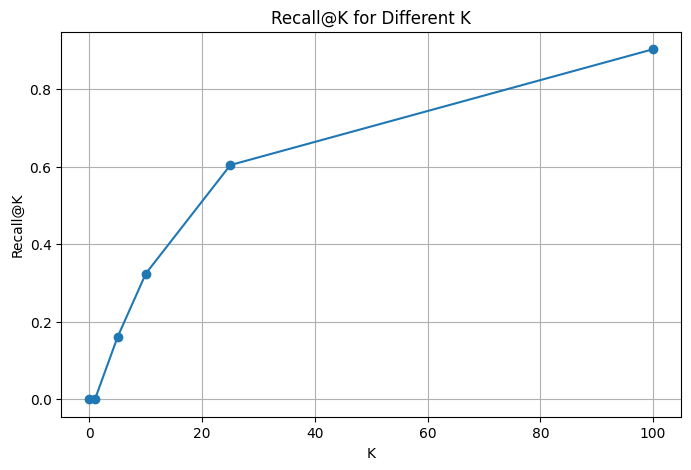

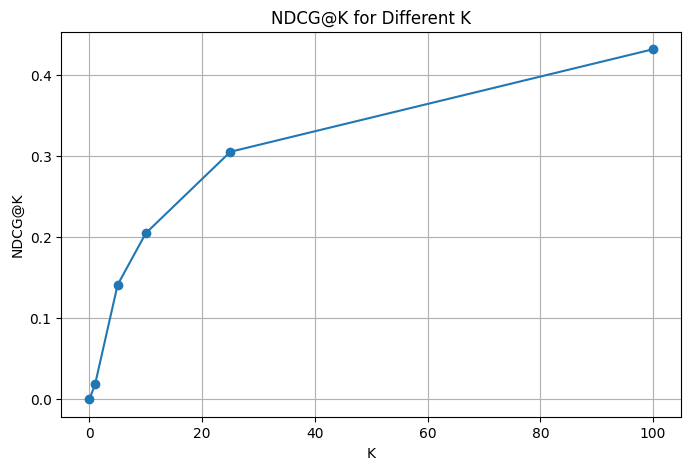

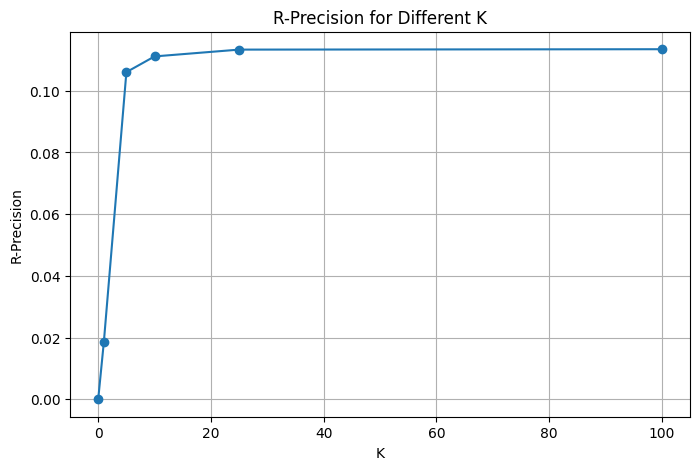

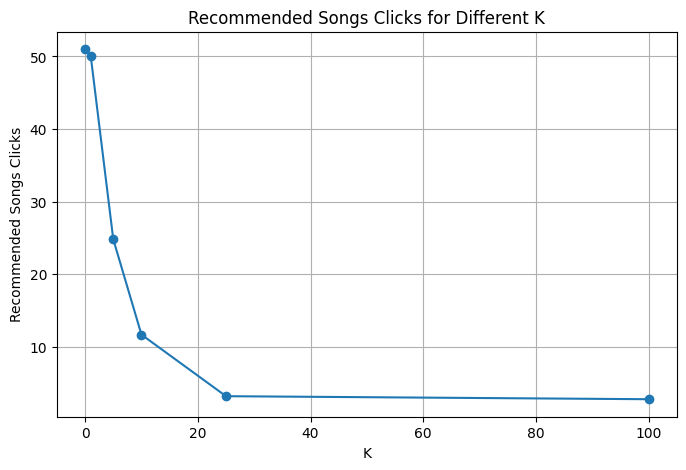

In [ ]:
# ks specified by the challenge
ks = [0, 1, 5, 10, 25, 100]

# Run evaluation across all ks
results = evaluate_model_across_k(model, validation_dataset, ks=ks, debug=False)

# Extract metrics for plotting
recall_at_k = [results[f"k={k}"]['Recall@K'] for k in ks]
ndcg_at_k = [results[f"k={k}"]['NDCG@K'] for k in ks]
r_precision_at_k = [results[f"k={k}"]['R-Precision'] for k in ks]
recommended_songs_clicks_at_k = [results[f"k={k}"]['Recommended Songs Clicks'] for k in ks]

# Plot each metric
# Recall@K
plt.figure(figsize=(8, 5))
plt.plot(ks, recall_at_k, marker='o')
plt.xlabel("K")
plt.ylabel("Recall@K")
plt.title("Recall@K for Different K")
plt.grid()
plt.show()

# NDCG@K
plt.figure(figsize=(8, 5))
plt.plot(ks, ndcg_at_k, marker='o')
plt.xlabel("K")
plt.ylabel("NDCG@K")
plt.title("NDCG@K for Different K")
plt.grid()
plt.show()

# R-Precision
plt.figure(figsize=(8, 5))
plt.plot(ks, r_precision_at_k, marker='o')
plt.xlabel("K")
plt.ylabel("R-Precision")
plt.title("R-Precision for Different K")
plt.grid()
plt.show()

# Recommended Songs Clicks
plt.figure(figsize=(8, 5))
plt.plot(ks, recommended_songs_clicks_at_k, marker='o')
plt.xlabel("K")
plt.ylabel("Recommended Songs Clicks")
plt.title("Recommended Songs Clicks for Different K")
plt.grid()
plt.show()


Input IDs Shape: (1122, 292)
Attention Mask Shape: (1122, 292)
Labels Shape: (1122, 292)
Aux Features Shape: (1122, 384)
Track Embeddings Shape: (1122, 292, 128)
Dataset Size: 1122, Batch Size: 4


Evaluating: 100%|██████████| 281/281 [02:00<00:00,  2.33batch/s]



Short Playlists Metrics:
k=0: {'Recall@K': 0.0, 'NDCG@K': 0.0, 'R-Precision': 0.0, 'Recommended Songs Clicks': 51.0}
k=1: {'Recall@K': 0.0, 'NDCG@K': 0.0, 'R-Precision': 0.0, 'Recommended Songs Clicks': 51.0}
k=5: {'Recall@K': 0.23181454836131093, 'NDCG@K': 0.1443455283039694, 'R-Precision': 0.03717026378896882, 'Recommended Songs Clicks': 18.973621103117505}
k=10: {'Recall@K': 0.30815347721822545, 'NDCG@K': 0.17078862831840722, 'R-Precision': 0.03717026378896882, 'Recommended Songs Clicks': 14.419664268585132}
k=25: {'Recall@K': 0.37410071942446044, 'NDCG@K': 0.18795819120659962, 'R-Precision': 0.03717026378896882, 'Recommended Songs Clicks': 15.129496402877697}
k=100: {'Recall@K': 0.49160671462829736, 'NDCG@K': 0.20951585490706565, 'R-Precision': 0.03717026378896882, 'Recommended Songs Clicks': 18.34052757793765}
Input IDs Shape: (1633, 292)
Attention Mask Shape: (1633, 292)
Labels Shape: (1633, 292)
Aux Features Shape: (1633, 384)
Track Embeddings Shape: (1633, 292, 128)
Dataset Si

Evaluating: 100%|██████████| 409/409 [02:54<00:00,  2.35batch/s]



Medium Playlists Metrics:
k=0: {'Recall@K': 0.0, 'NDCG@K': 0.0, 'R-Precision': 0.0, 'Recommended Songs Clicks': 51.0}
k=1: {'Recall@K': 0.0, 'NDCG@K': 0.0, 'R-Precision': 0.0, 'Recommended Songs Clicks': 51.0}
k=5: {'Recall@K': 0.23647890050329073, 'NDCG@K': 0.15857668739305866, 'R-Precision': 0.10456493078444298, 'Recommended Songs Clicks': 23.775214238628873}
k=10: {'Recall@K': 0.508836362494899, 'NDCG@K': 0.27183553281898853, 'R-Precision': 0.10914137133649328, 'Recommended Songs Clicks': 9.379037574159526}
k=25: {'Recall@K': 0.9621033053959883, 'NDCG@K': 0.43230527015140086, 'R-Precision': 0.10914137133649328, 'Recommended Songs Clicks': 1.4588002636783124}
k=100: {'Recall@K': 1.0, 'NDCG@K': 0.4436944366617579, 'R-Precision': 0.10914137133649328, 'Recommended Songs Clicks': 1.2089650626235993}
Input IDs Shape: (1471, 292)
Attention Mask Shape: (1471, 292)
Labels Shape: (1471, 292)
Aux Features Shape: (1471, 384)
Track Embeddings Shape: (1471, 292, 128)
Dataset Size: 1471, Batch Si

Evaluating: 100%|██████████| 368/368 [02:36<00:00,  2.36batch/s]



Long Playlists Metrics:
k=0: {'Recall@K': 0.0, 'NDCG@K': 0.0, 'R-Precision': 0.0, 'Recommended Songs Clicks': 51.0}
k=1: {'Recall@K': 0.0016289987554343544, 'NDCG@K': 0.03942895989123046, 'R-Precision': 0.03942895989123046, 'Recommended Songs Clicks': 49.02855200543848}
k=5: {'Recall@K': 0.04177296677320105, 'NDCG@K': 0.11587697220298215, 'R-Precision': 0.1268505870836265, 'Recommended Songs Clicks': 25.031271244051666}
k=10: {'Recall@K': 0.09114996125223258, 'NDCG@K': 0.12997552438475737, 'R-Precision': 0.13421345833507586, 'Recommended Songs Clicks': 11.808973487423522}
k=25: {'Recall@K': 0.23732414753258546, 'NDCG@K': 0.18553709735589058, 'R-Precision': 0.13873292673417423, 'Recommended Songs Clicks': 2.4711080897348743}
k=100: {'Recall@K': 0.8694671297514048, 'NDCG@K': 0.4616840221735553, 'R-Precision': 0.13822829234136963, 'Recommended Songs Clicks': 1.2821210061182868}


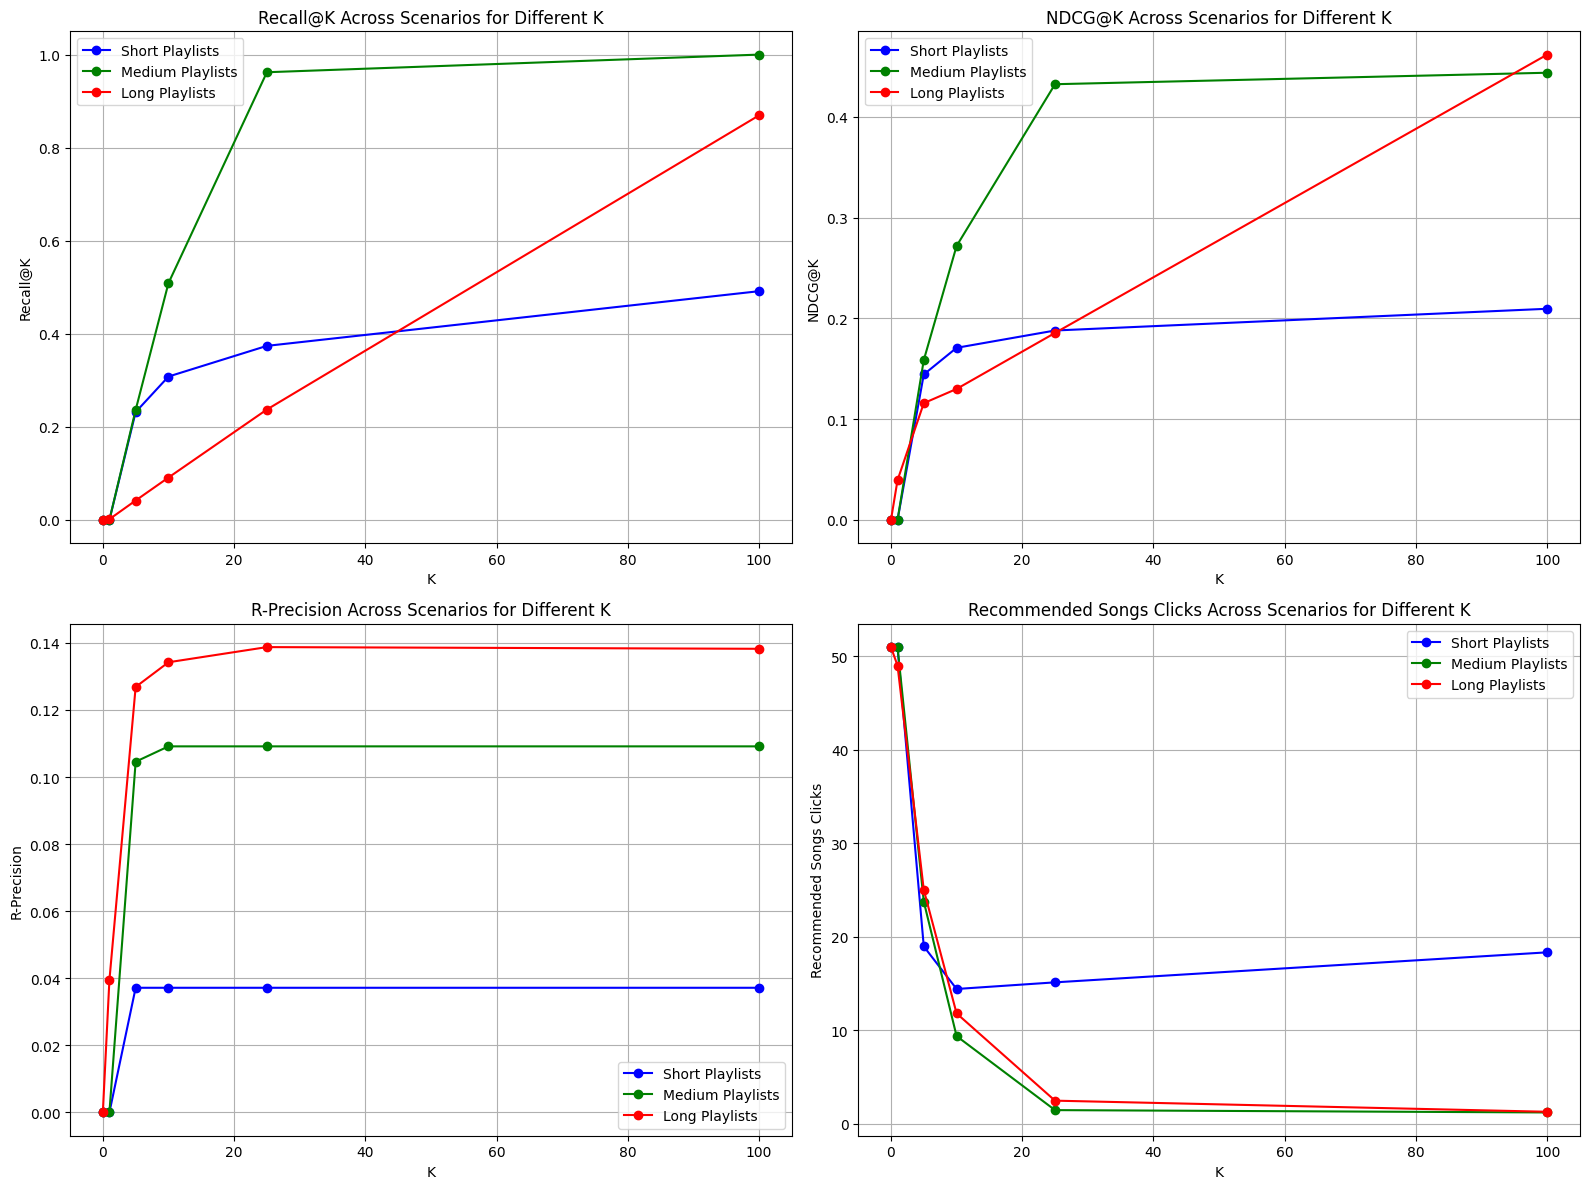

In [ ]:
# Define scenarios based on playlist length
short_playlists = validation_df[validation_df['track_sequence'].apply(len) < 10]
medium_playlists = validation_df[(validation_df['track_sequence'].apply(len) >= 10) &
                                 (validation_df['track_sequence'].apply(len) <= 30)]
long_playlists = validation_df[validation_df['track_sequence'].apply(len) > 30]

# Group the datasets
scenarios = {
    "Short Playlists": short_playlists,
    "Medium Playlists": medium_playlists,
    "Long Playlists": long_playlists
}

scenario_metrics = {}

ks = [0, 1, 5, 10, 25, 100]  # Challenge-specified ks

for scenario_name, scenario_data in scenarios.items():
    # Prepare inputs
    inputs = prepare_bert4rec_inputs(scenario_data, track_embeddings_matrix, max_seq_length=292)
    dataset = create_dataset(inputs)

    # Evaluate model across ks
    results = evaluate_model_across_k(model, dataset, ks=ks, debug=False)
    scenario_metrics[scenario_name] = results
    print(f"\n{scenario_name} Metrics:")
    for k in ks:
        print(f"k={k}: {results[f'k={k}']}")

# Extract and plot metrics for each scenario and k
fig, axs = plt.subplots(2, 2, figsize=(16, 12))
metric_names = ['Recall@K', 'NDCG@K', 'R-Precision', 'Recommended Songs Clicks']
colors = ['b', 'g', 'r', 'm']  # Different colors for each scenario

for i, metric_name in enumerate(metric_names):
    ax = axs[i // 2, i % 2]  # Identify subplot
    for scenario_name, color in zip(scenario_metrics.keys(), colors):
        metric_values = [scenario_metrics[scenario_name][f'k={k}'][metric_name] for k in ks]
        ax.plot(ks, metric_values, marker='o', label=scenario_name, color=color)

    # Customize subplot
    ax.set_xlabel("K")
    ax.set_ylabel(metric_name)
    ax.set_title(f"{metric_name} Across Scenarios for Different K")
    ax.legend()
    ax.grid()

# Adjust layout and show plot
plt.tight_layout()
plt.show()

Input IDs Shape: (1122, 292)
Attention Mask Shape: (1122, 292)
Labels Shape: (1122, 292)
Aux Features Shape: (1122, 384)
Track Embeddings Shape: (1122, 292, 128)
Dataset Size: 1122, Batch Size: 4


Evaluating: 100%|██████████| 281/281 [01:53<00:00,  2.47batch/s]


Short Playlists: {'Recall@K': 0.30815347721822545, 'NDCG@K': 0.17078862831840722, 'R-Precision': 0.03717026378896882, 'Recommended Songs Clicks': 14.419664268585132}
Input IDs Shape: (1633, 292)
Attention Mask Shape: (1633, 292)
Labels Shape: (1633, 292)
Aux Features Shape: (1633, 384)
Track Embeddings Shape: (1633, 292, 128)
Dataset Size: 1633, Batch Size: 4


Evaluating: 100%|██████████| 409/409 [02:44<00:00,  2.48batch/s]


Medium Playlists: {'Recall@K': 0.508836362494899, 'NDCG@K': 0.27183553281898853, 'R-Precision': 0.10914137133649328, 'Recommended Songs Clicks': 9.379037574159526}
Input IDs Shape: (1471, 292)
Attention Mask Shape: (1471, 292)
Labels Shape: (1471, 292)
Aux Features Shape: (1471, 384)
Track Embeddings Shape: (1471, 292, 128)
Dataset Size: 1471, Batch Size: 4


Evaluating: 100%|██████████| 368/368 [02:28<00:00,  2.48batch/s]

Long Playlists: {'Recall@K': 0.09114996125223258, 'NDCG@K': 0.12997552438475737, 'R-Precision': 0.13421345833507586, 'Recommended Songs Clicks': 11.808973487423522}


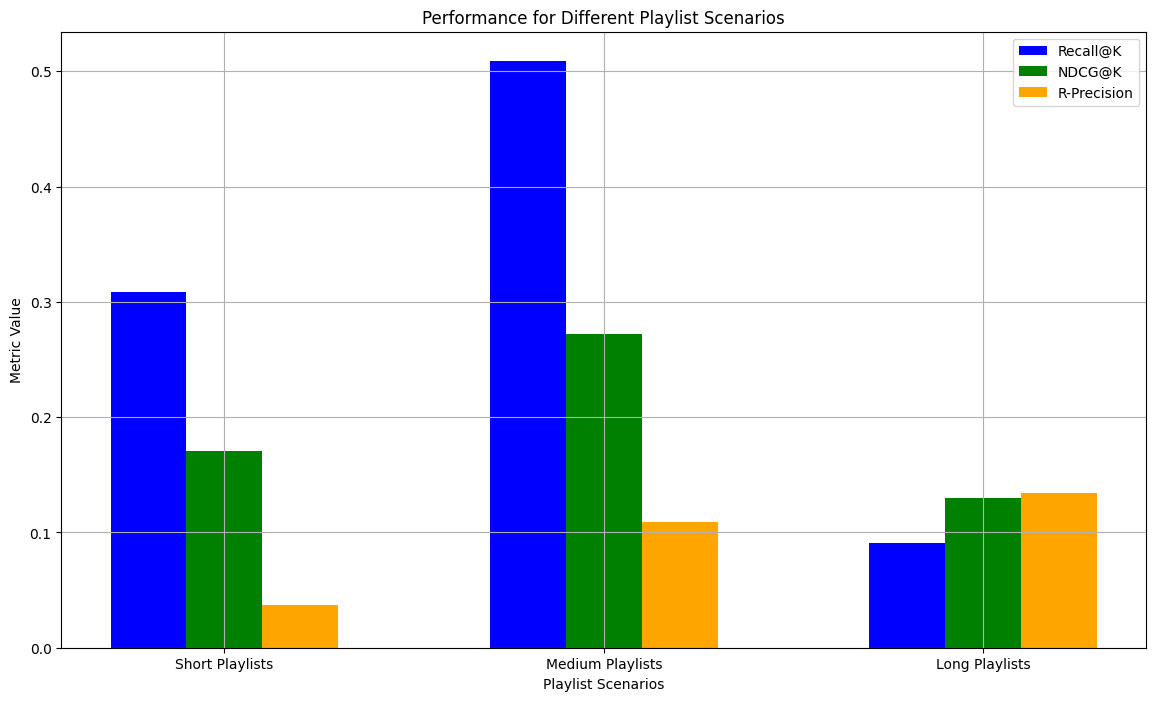

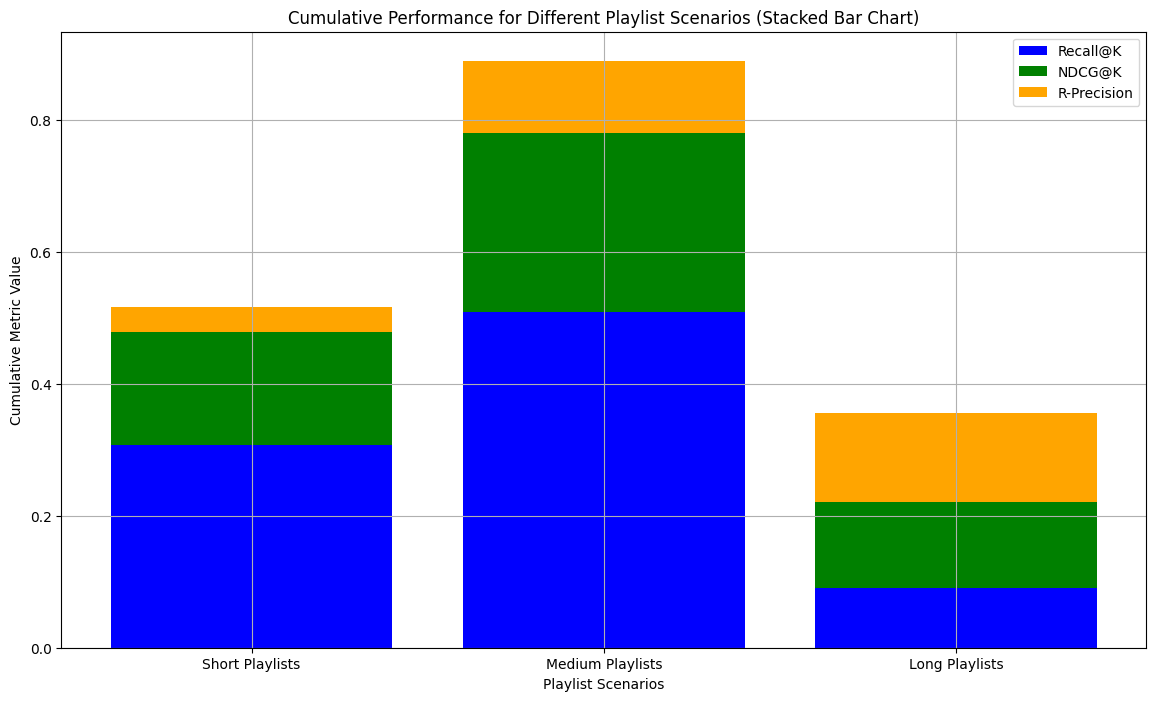

In [ ]:
# Define scenarios based on playlist length
short_playlists = validation_df[validation_df['track_sequence'].apply(len) < 10]
medium_playlists = validation_df[(validation_df['track_sequence'].apply(len) >= 10) &
                                 (validation_df['track_sequence'].apply(len) <= 30)]
long_playlists = validation_df[validation_df['track_sequence'].apply(len) > 30]

# Group the datasets
scenarios = {
    "Short Playlists": short_playlists,
    "Medium Playlists": medium_playlists,
    "Long Playlists": long_playlists
}
scenario_metrics = {}

for scenario_name, scenario_data in scenarios.items():
    # Prepare inputs
    inputs = prepare_bert4rec_inputs(scenario_data, track_embeddings_matrix, max_seq_length=292)
    dataset = create_dataset(inputs)

    # Evaluate model
    results = evaluate_model(model, dataset, k=10,debug=False)
    scenario_metrics[scenario_name] = results
    print(f"{scenario_name}: {results}")
# Extract metrics
scenarios_list = list(scenario_metrics.keys())
recalls = [scenario_metrics[scenario]['Recall@K'] for scenario in scenarios_list]
ndcgs = [scenario_metrics[scenario]['NDCG@K'] for scenario in scenarios_list]
r_precisions = [scenario_metrics[scenario]['R-Precision'] for scenario in scenarios_list]
clicks = [scenario_metrics[scenario]['Recommended Songs Clicks'] for scenario in scenarios_list]


# Define bar positions
x = np.arange(len(scenarios_list))  # Number of scenarios
bar_width = 0.2

# Create subplots for metrics
plt.figure(figsize=(14, 8))

# Plot Recall@K
plt.bar(x - bar_width, recalls, width=bar_width, label='Recall@K', color='blue')
# Plot NDCG@K
plt.bar(x, ndcgs, width=bar_width, label='NDCG@K', color='green')
# Plot R-Precision
plt.bar(x + bar_width, r_precisions, width=bar_width, label='R-Precision', color='orange')

# Add labels, title, and legend
plt.xticks(x, scenarios_list)
plt.xlabel("Playlist Scenarios")
plt.ylabel("Metric Value")
plt.title("Performance for Different Playlist Scenarios")
plt.legend()
plt.grid()
plt.show()


plt.figure(figsize=(14, 8))

# Plot stacked bars
plt.bar(scenarios_list, recalls, label='Recall@K', color='blue')
plt.bar(scenarios_list, ndcgs, bottom=recalls, label='NDCG@K', color='green')
plt.bar(scenarios_list, r_precisions, bottom=np.array(recalls) + np.array(ndcgs), label='R-Precision', color='orange')

# Add labels, title, and legend
plt.xlabel("Playlist Scenarios")
plt.ylabel("Cumulative Metric Value")
plt.title("Cumulative Performance for Different Playlist Scenarios (Stacked Bar Chart)")
plt.legend()
plt.grid()
plt.show()
